# T-ECD: расширенный EDA и готовность к рекомендательной системе

**Цель:** воспроизвести основные направления анализа авторов T‑ECD и дополнить их аудитом качества, аномалий, смещения выборки и временной утечки. Анализ и пояснения — на русском языке. Дата изучения источников: **7 сентября 2026**.

> **Три разных уровня доказательств.**  
> **[CARD]** — утверждения авторов о T‑ECD Small/Full; **[SAVED]** — агрегаты из сохранённого вывода прежнего `eda.ipynb`; **[LOCAL]** — вычисления на реально доступных локальных Parquet. Эти уровни не объединяются в одну «статистику датасета». Синтетические данные используются **только в тестах**, не в выводах EDA.

### Главное из уже доступных результатов
- Прежние **2 млн строк** — префикс **одного дня (1250)** и **двух доменов**. Это не запрошенные 59 дней и не все три товарных домена. На таком срезе нельзя исследовать динамику или валидировать временную модель.
- **96,84% событий — `view`**; `clickout` и `like` отсутствуют в исходной положительной маске. Цель рекомендаций нужно определить явно, а не сводить неизвестные действия к просмотрам или ко всем позитивам.
- Общие пропуски контекста (~66,38%) почти совпадают с долей Offers. Это **кандидат на структурное отсутствие полей**, а не основание удалять две трети данных.
- Аудит кода выявляет **отбрасывание `timestamp`, отсутствие purge-gap, оценку RF на обучающих для RF строках и несовместимость строковых item ID с API**. Ниже — точные границы утверждений и план исправлений; обучение/сервис здесь не меняются.

Если сырых файлов нет, ноутбук выполняется до конца: показывает сохранённые доказательства, а новые проверки помечает **«не выполнено»**, не подставляя вымышленные данные.

### Содержание
1. [Основа анализа и ограничения источника](#source)
2. [Воспроизводимость и параметры](#config)
3. [Повторный разбор сохранённых результатов](#saved)
4. [Инвентаризация и схема сырых файлов](#inventory)
5. [Выборка без префиксного смещения](#sampling)
6. [Пропуски, идентификаторы и словарь действий](#quality)
7. [Время, всплески и дрейф](#time)
8. [Long tail, разреженность, повторы и цепочки](#behavior)
9. [Каталоги, cross-domain, пользователи и эмбеддинги](#catalogs)
10. [Цена, количество, Reviews и Payments](#numeric)
11. [Purged split и cold start](#split)
12. [Реестр аномалий и рекомендации для проекта](#conclusions)

<a id="source"></a>
## 1. Основа: что именно проверяем вслед за авторами

Основной источник — [dataset card T‑ECD](https://huggingface.co/datasets/t-tech/T-ECD), [зафиксированная редакция](https://huggingface.co/datasets/t-tech/T-ECD/blob/c55530a7a179f06330ff626d35634d20c8a56f43/README.md). Вспомогательные: [статья KDD ’26](https://doi.org/10.1145/3770855.3817588), [официальный baseline preprocessing](https://github.com/kliakhnovich/tecd-baselines/blob/a98afa7bbe97c64caea0499b90e9900b9793fbb8/scripts/preprocess.py). Числа ниже — **округлённые данные CARD**, не наши измерения; результаты моделей из статьи не воспроизводились.

| Характеристика [CARD] | Small | Full | Что проверяем локально |
|---|---:|---:|---|
| События | ~1 млрд | ~135 млрд | Размеры из Parquet footer и реально прочитанные строки |
| Пользователи | ~3,5 млн | ~44 млн | Активность, наблюдаемый overlap, новые для истории пользователи |
| Товары | ~2,6 млн | ~30 млн | Разреженность, long tail, согласованность с каталогами |
| Бренды | ~29 тыс. | ~1 млн | Связи через общие `brand_id`, происхождение бренда |
| История | 200+ дней | 1300+ дней | Доступность каждого домена, разрывы, границы окна |
| Домены | 4, **без Payments** | 5 | Payments не считаем «потерянными» в Small |

**Семантика и ограничения CARD:**
1. `user_id` и `brand_id` согласованы между доменами; это не гарантия единого пространства `item_id`. Для item-рекомендаций используем `(domain, item_id)`. Связи receipts с товарными каталогами требуют отдельной проверки; совпадения голого ID недостаточно.
2. Глубина истории доменов различается из-за жизненного цикла сервисов и хранения данных. Отсутствующий локальный файл ≠ нулевая активность ≠ доказанный пробел в публикации.
3. Анонимизация включает jitter времени, возмущение чисел, обобщение редких значений, удаление и синтетическую инъекцию событий. Нарушенная цепочка, редкая категория или всплеск — **кандидаты для проверки**, не доказательства мошенничества/ботов.
4. **Минимум 12 часов между последним событием истории и моментом прогноза** — в train/validation/test и во всех вспомогательных доменах. Это не только удаление финальных 12 часов всего датасета. В baseline авторов используются целые gap-дни.
5. Ratings — явная обратная связь по **брендам**, текст не опубликован; эмбеддинги не раскрывают исходный текст. Цена/количество/категории/OS могут быть недоступны в части схем. Наличие поля в описании не означает его наличие в каждом event-файле.

Лицензия данных: **CC BY-NC-SA 4.0** (некоммерческое использование, атрибуция и ShareAlike). Сырые данные и отчёты текущего запуска сохраняются только под игнорируемым `data/`.

<a id="config"></a>
## 2. Воспроизводимость и параметры

Для EDA не нужны `implicit`, MLflow и запуск API:

```bash
python -m pip install -r requirements-eda.txt
jupyter nbconvert --to notebook --execute --inplace eda.ipynb --ExecutePreprocessor.timeout=600
python -m pytest -q tests
```

Ноутбук **ничего не скачивает автоматически**. Сначала загрузите данные через `loader.ipynb`/официальный downloader, затем проверьте manifest ниже. Старый блок retry/download удалён из EDA: там был не определён `RateLimitError`, игнорировался возвращаемый список failed-файлов, а сообщения об успехе соседствовали с HTTP 429. Прогресс загрузчика и наличие каталога не заменяют проверку Parquet footer.

Чтобы закрепить версию данных, можно отдельно использовать **один** `snapshot_download` с `revision="c55530a7a179f06330ff626d35634d20c8a56f43"` и точным `allow_patterns` для каталогов/дней. Не скачивайте Full целиком. Токен, если нужен, задавайте через окружение, не вписывайте в ноутбук. Для масштабирования расширяйте последовательное окно, а не берите первые строки.

`TIME_CONFIG` намеренно пуст: единицу и начало отсчёта числового времени **нельзя угадывать**. `DAY_ZERO` задаётся только после подтверждения соответствия номера партиции календарю. Все настройки и версии библиотек попадут в отчёт. Дефолтная выборка ограничена 1 млн скалярных строк; чтение проходит по всем выбранным файлам, поэтому I/O зависит от всего локального окна.

In [1]:
import hashlib
import importlib.metadata as im
import json
import os
import platform
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import seaborn as sns
from IPython.display import Markdown, display

import tecd_eda
from tecd_eda import (
    ITEM_DOMAINS, balanced_plan, cold_start_table, dataset_inventory, degree_summary,
    duplicate_profile, embedding_profile, find_eda_root, join_catalog,
    jensen_shannon, load_eda_sample, numeric_profile, overlap_table,
    purged_day_split, purged_history, robust_scores, sample_parquet,
    scan_catalog, schema_missingness, valid_id,
)

PROJECT_DIR = Path(tecd_eda.__file__).resolve().parent
DATA_DIR = Path(os.getenv("TECD_EDA_DATA_DIR", str(PROJECT_DIR / "data/t_ecd")))
VARIANT = os.getenv("TECD_EDA_VARIANT", "small")
default_domains = (*ITEM_DOMAINS, "reviews") + (("payments",) if VARIANT == "full" else ())
DOMAINS = tuple(d.strip() for d in os.getenv("TECD_EDA_DOMAINS", ",".join(default_domains)).split(",") if d.strip())
DAY_BEGIN = int(os.getenv("TECD_EDA_DAY_BEGIN", "1250"))
DAY_END = int(os.getenv("TECD_EDA_DAY_END", "1308"))
MAX_EVENT_ROWS = int(os.getenv("TECD_EDA_MAX_ROWS", "1000000"))
SEED = int(os.getenv("TECD_EDA_SEED", "42"))
MAX_CATALOG_KEYS = 1_000_000  # предел памяти для ТОЧНОЙ глобальной уникальности каталога
MAX_EMBEDDING_ROWS = 2_000   # общий бюджет строк с векторами по всем файлам
MIN_TREND_DAYS = 14
MIN_GROUP_ROWS = 100
VAL_DAYS, TEST_DAYS, GAP_DAYS = 2, 2, 1
TIME_CONFIG = {}  # Например, ТОЛЬКО после проверки: {"retail": {"column": "timestamp", "unit": "s", "origin": "unix"}}
DAY_ZERO = None  # Например pd.Timestamp(..., tz="UTC"), если day=0 действительно соответствует этой дате
PREDICTION_TIME = None  # Явный timezone-aware момент для дополнительной проверки точного 12h gap
RATING_RANGE = None  # Шкалу rating CARD не задаёт: не объявляем значения вне 1..5 ошибками без словаря
REPORT_DIR = Path(os.getenv("TECD_EDA_REPORT_DIR", str(PROJECT_DIR / "data/eda_reports/latest")))

assert DAY_BEGIN <= DAY_END
assert VARIANT in {"small", "full"}
assert not (VARIANT == "small" and "payments" in DOMAINS), "Payments отсутствует в Small по CARD"

sns.set_theme(style="whitegrid", palette="colorblind", font="DejaVu Sans")
plt.rcParams.update({"figure.figsize": (11, 4.5), "figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 24)
pd.set_option("display.max_colwidth", 95)
pd.set_option("display.float_format", lambda v: f"{v:,.5g}")

ARTIFACTS, FINDINGS = {}, []
def table(name, frame, limit=20):
    ARTIFACTS[name] = frame.copy()
    if frame.empty:
        display(Markdown(f"**{name}:** нет наблюдений / проверка неприменима. Это не нулевая частота аномалий."))
    else:
        display(frame.head(limit))
        if len(frame) > limit:
            display(Markdown(f"Показано {limit} из {len(frame)} строк; полная таблица — в отчёте `{tecd_eda.report_filename(name)}`."))

def finding(code, priority, status, scope, evidence, action):
    FINDINGS.append(dict(check=code, priority=priority, status=status, scope=scope, evidence=evidence, recommendation=action))

def skipped(check, reason="Нет локальных строк событий; нужны реальные Parquet."):
    display(Markdown(f"**Не выполнено — {check}.** {reason}"))
    finding(check, "—", "не выполнено", "LOCAL", reason, "Повторить на проверенном локальном окне; не заменять синтетическими результатами.")

RUN_INFO = {
    "run_utc": datetime.now(timezone.utc).isoformat(), "data_dir": str(DATA_DIR), "variant": VARIANT,
    "domains": list(DOMAINS), "day_begin": DAY_BEGIN, "day_end": DAY_END,
    "sampling": "uniform_without_replacement_within_each_file_equal_budget_waterfill",
    "max_event_rows": MAX_EVENT_ROWS, "seed": SEED, "time_config": TIME_CONFIG,
    "day_zero": str(DAY_ZERO), "prediction_time": str(PREDICTION_TIME), "rating_range": RATING_RANGE,
    "naive_datetime_timezone_assumption": "UTC; confirm before backtest",
    "max_catalog_keys": MAX_CATALOG_KEYS, "max_embedding_rows": MAX_EMBEDDING_ROWS,
    "min_trend_days": MIN_TREND_DAYS, "min_group_rows": MIN_GROUP_ROWS,
    "val_days": VAL_DAYS, "test_days": TEST_DAYS, "gap_days": GAP_DAYS,
    "python": platform.python_version(),
    "packages": {name: im.version(name) for name in ("numpy", "pandas", "pyarrow", "matplotlib", "seaborn", "nbformat")},
    "analysis_helper_sha256": hashlib.sha256(Path(tecd_eda.__file__).read_bytes()).hexdigest(),
    "card_revision": "c55530a7a179f06330ff626d35634d20c8a56f43",
    "local_data_revision": "unknown — verify against download provenance; card_revision is not a local data hash",
}
display(Markdown(f"**Режим:** локальные данные `{VARIANT}`, дни {DAY_BEGIN}–{DAY_END}, домены {', '.join(DOMAINS)}; seed={SEED}."))

**Режим:** локальные данные `small`, дни 1250–1308, домены marketplace, retail, offers, reviews; seed=42.

<a id="saved"></a>
## 3. Повторный разбор сохранённых результатов [SAVED]

`eda_reference.json` — небольшой **архив агрегатов**, извлечённых из outputs ячеек 10, 11 и 13 (нумерация с нуля) прежнего ноутбука в коммите `6f6b122c245f24be9a313c1491b753359f449abb`. Это **не свежий запуск на сырых данных**, не репрезентативная выборка Small и не восстановленные строки событий. Источник и точность округления сохранены в JSON.

Так сохраняются полезные доказательства исходного исследования без многократных HTTP-логов и без смешения со следующим локальным запуском.

,domain,events,users,items,event_share_pct,events_per_observed_user,events_per_observed_item
0,marketplace,672535,78635,71533,33.627,8.5526,9.4017
1,offers,1327465,131036,838,66.373,10.131,"1,584.1"


,domain,action_type,events,in_original_positive_mask,share_within_domain_pct
1,marketplace,view,652666,False,97.046
3,marketplace,click,17453,True,2.5951
5,marketplace,clickout,2222,False,0.33039
7,marketplace,like,194,False,0.028846
0,offers,view,1284069,False,96.731
2,offers,click,35626,True,2.6838
4,offers,clickout,7007,False,0.52785
6,offers,like,763,False,0.057478


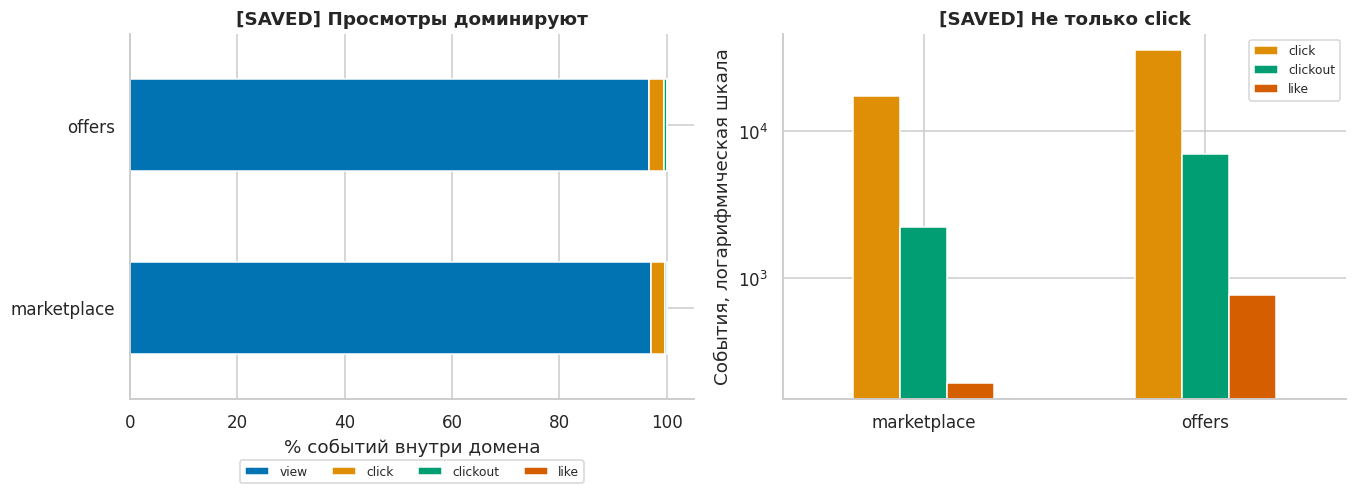

**Пересчёт:** `view` = 1,936,735 / 2,000,000 = **96.8368%**; в исходную positive-mask попадает только **2.6540%** строк. Отдельно остаются **10,186** `clickout`/`like` (их позитивность зависит от выбранной цели). Из 59 запрошенных дней в outputs — 1; отсутствующий домен — **retail**.

In [2]:
reference = json.loads((PROJECT_DIR / "eda_reference.json").read_text(encoding="utf-8"))
observed = reference["observed"]
legacy_domains = pd.DataFrame(observed["by_domain"]).set_index("domain")
legacy_actions = pd.DataFrame(observed["by_action"])
assert legacy_domains.events.sum() == legacy_actions.events.sum() == observed["rows"]
legacy_domains["event_share_pct"] = 100 * legacy_domains.events / observed["rows"]
legacy_domains["events_per_observed_user"] = legacy_domains.events / legacy_domains.users
legacy_domains["events_per_observed_item"] = legacy_domains.events / legacy_domains["items"]
table("saved_domain_summary", legacy_domains.reset_index())

original_positive_actions = {"click", "add_to_cart", "add-to-cart", "cart", "order", "purchase", "transition"}
legacy_actions["in_original_positive_mask"] = legacy_actions.action_type.isin(original_positive_actions)
legacy_actions["share_within_domain_pct"] = 100 * legacy_actions.events / legacy_actions.domain.map(legacy_domains.events)
table("saved_action_summary", legacy_actions.sort_values(["domain", "events"], ascending=[True, False]))

legacy_action_matrix = legacy_actions.pivot(index="domain", columns="action_type", values="events").fillna(0)
legacy_action_matrix = legacy_action_matrix.reindex(columns=["view", "click", "clickout", "like"])
action_colors = dict(zip(legacy_action_matrix.columns, sns.color_palette("colorblind", 4)))
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.7))
(legacy_action_matrix.div(legacy_action_matrix.sum(axis=1), axis=0) * 100).plot.barh(stacked=True, ax=axes[0], color=[action_colors[c] for c in legacy_action_matrix])
axes[0].set(xlabel="% событий внутри домена", ylabel="", title="[SAVED] Просмотры доминируют")
axes[0].legend(fontsize=8, loc="upper center", bbox_to_anchor=(.5, -.15), ncol=4)
legacy_action_matrix.drop(columns="view").plot.bar(ax=axes[1], logy=True, color=[action_colors[c] for c in ("click", "clickout", "like")])
axes[1].set(xlabel="", ylabel="События, логарифмическая шкала", title="[SAVED] Не только click")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show(); plt.close(fig)

legacy_totals = legacy_actions.groupby("action_type").events.sum()
views = int(legacy_totals.get("view", 0))
missed_engagement = int(legacy_totals.reindex(["clickout", "like"], fill_value=0).sum())
requested_days = reference["requested"]["day_end"] - reference["requested"]["day_begin"] + 1
missing_domains = set(reference["requested"]["domains"]) - set(legacy_domains.index)
display(Markdown(
    f"**Пересчёт:** `view` = {views:,} / {observed['rows']:,} = **{views / observed['rows']:.4%}**; "
    f"в исходную positive-mask попадает только **{legacy_totals['click'] / observed['rows']:.4%}** строк. "
    f"Отдельно остаются **{missed_engagement:,}** `clickout`/`like` (их позитивность зависит от выбранной цели). "
    f"Из {requested_days} запрошенных дней в outputs — {len(observed['days'])}; отсутствующий домен — **{', '.join(sorted(missing_domains))}**."
))
finding("S01_prefix_bias", "P0", "подтверждено", "SAVED", "2 000 000 строк; только день 1250, marketplace/offers; retail отсутствует.", "Не использовать префикс как временную выборку; покрыть все domain×day и проверить manifest.")
finding("S02_views_and_action_mask", "P0", "подтверждено", "SAVED+CODE", f"view={views / observed['rows']:.4%}; {missed_engagement:,} clickout/like вне исходной positive-mask.", "Явная domain-specific цель; сравнить click и clickout как разные задачи, like — отдельный слабый сигнал.")

In [3]:
# Inclusion–exclusion применим именно к двум наблюдаемым доменам и общей unique-статистике этих же outputs.
legacy_intersection = int(legacy_domains.users.sum() - observed["users"])
legacy_item_intersection = int(legacy_domains["items"].sum() - observed["items_raw_id"])
assert 0 <= legacy_intersection <= legacy_domains.users.min()
assert legacy_item_intersection >= 0
legacy_overlap = pd.DataFrame([{
    "scope": "SAVED marketplace ∩ offers", "shared_users": legacy_intersection,
    "user_union": observed["users"], "user_jaccard": legacy_intersection / observed["users"],
    "p_offers_given_marketplace": legacy_intersection / legacy_domains.loc["marketplace", "users"],
    "p_marketplace_given_offers": legacy_intersection / legacy_domains.loc["offers", "users"],
    "shared_raw_item_ids": legacy_item_intersection,
}])
table("saved_cross_domain_overlap", legacy_overlap)
legacy_missing = pd.Series(observed["missing_share_rounded"], name="pooled_missing_share_rounded").to_frame()
table("saved_missingness", legacy_missing.reset_index(names="field"))
display(Markdown(
    f"**Связность в исходном префиксе:** {legacy_intersection:,} общих пользователей, Jaccard **{legacy_intersection / observed['users']:.2%}**. "
    "Это обосновывает проверку переноса user-признаков, но не обещает его эффективность. "
    f"Совпадений голого `item_id` между этими двумя наблюдаемыми наборами — **{legacy_item_intersection}**, не гарантия для других дней/доменов. "
    f"Доля Offers — **{legacy_domains.loc['offers', 'event_share_pct']:.5f}%**: она близка к pooled null-rate OS/subdomain. "
    "Без сырых схем нельзя разложить эти пропуски по доменам. В частности, `timestamp` отсутствует в сохранённом DataFrame, "
    "но **это не означает его отсутствия в Parquet**: исходный loader не включал его в `keep`."
))
finding("S03_context_nulls", "P1", "кандидат", "SAVED", "pooled missing os=0.663732, subdomain=0.663829; доля Offers=0.6637325.", "Проверить наличие полей в raw-схемах и null-rate только там, где поле существует; использовать missing/not_applicable indicators.")
finding("S04_string_item_ids", "P0", "подтверждено", "SAVED+CODE", "В head исходного ноутбука item_id имеет префикс nfmcg_; API приводит item к int.", "Хранить строковые доменные item ID на всех стадиях и в контракте ответа.")

,scope,shared_users,user_union,user_jaccard,p_offers_given_marketplace,p_marketplace_given_offers,shared_raw_item_ids
0,SAVED marketplace ∩ offers,20078,189593,0.1059,0.25533,0.15323,0


,field,pooled_missing_share_rounded
0,subdomain,0.66383
1,os,0.66373
2,user_id,0
3,action_type,0
4,item_id,0
5,domain,0
6,day,0


**Связность в исходном префиксе:** 20,078 общих пользователей, Jaccard **10.59%**. Это обосновывает проверку переноса user-признаков, но не обещает его эффективность. Совпадений голого `item_id` между этими двумя наблюдаемыми наборами — **0**, не гарантия для других дней/доменов. Доля Offers — **66.37325%**: она близка к pooled null-rate OS/subdomain. Без сырых схем нельзя разложить эти пропуски по доменам. В частности, `timestamp` отсутствует в сохранённом DataFrame, но **это не означает его отсутствия в Parquet**: исходный loader не включал его в `keep`.

### Выводы из SAVED — и чего эти результаты не доказывают

1. **Выборка смещена механизмом загрузки.** Даже чередование файлов по дням/доменам не спасает: глобальный `max_rows` обрывает чтение внутри раннего файла. Retail и будущие дни могут полностью исчезнуть. Доля просмотров и overlap относятся только к этому префиксу.
2. **Offers и Marketplace — разные задачи по масштабу пространства товаров.** 838 наблюдаемых offers против 71 533 marketplace items при большем числе событий в Offers. Среднее событий на item существенно различается; это аргумент за раздельную нормировку и macro-метрики доменов, **не** измерение Gini/популярностного хвоста.
3. **Общий user ID даёт реальную точку связки**: 20 078 пользователей присутствуют в обоих наблюдаемых доменах. При переносе нельзя брать активность из «будущего» другого домена. Для брендов сохранённых агрегатов недостаточно.
4. **Не устанавливаем причин по совпадению долей пропусков.** Нужны схемы и conditional missingness; значения null в неизвестном поле нельзя автоматически заменить нулём цены/возрастом/категорией.
5. **Неизмерены на SAVED:** точные дубликаты, хвост активности, разреженность по уникальным парам, ценовые выбросы, покрытия каталогов, cold-start, сезонность, временной дрейф и качество моделей. Ниже это самостоятельные вычислимые проверки; если raw нет, они честно пропускаются.

<a id="inventory"></a>
## 4. Инвентаризация: сначала доказываем, что именно скачано [LOCAL]

Footer даёт точное число строк **локального файла**, но не пользователей и не размер всего T‑ECD. Проверяем: отсутствующие/пустые/повреждённые файлы, некорректные имена дней, две партиции одного logical day, смену схемы. Каталоги не обязательны для discovery корня, но обязательны для соответствующих referential checks.

`missing` означает «нет в выбранном локальном окне», `empty` — реально прочитанный файл с нулём строк. При двух именах вида `1.pq`/`00001.pq` обе партиции исключаются из расчётов до выяснения причины. Данные Payments/receipts не смешиваются с товарными событиями, Reviews читаются из `reviews/{day}.pq`.

In [4]:
root = find_eda_root(DATA_DIR, variant=VARIANT)
inventory = dataset_inventory(root, DOMAINS, DAY_BEGIN, DAY_END)
RUN_INFO["resolved_root"] = str(root) if root else None
if root is None:
    skipped("L00_raw_data", f"В {DATA_DIR} не найдена структура T-ECD. Показанные выше SAVED-агрегаты не заменяют raw; сетевой загрузки в EDA нет.")
else:
    inventory_summary = inventory.groupby(["role", "domain", "status"], dropna=False).agg(
        files=("relative_path", "size"), footer_rows=("rows", lambda x: x.sum(min_count=1)),
        disk_mib=("bytes", lambda x: x.sum(min_count=1) / 2**20),
    ).reset_index()
    table("inventory_summary", inventory_summary, limit=30)
    table("inventory_issues", inventory.loc[~inventory.status.eq("ok"), ["relative_path", "role", "day", "status", "rows", "error"]])
    issues = inventory[~inventory.status.isin(["ok", "empty"])]
    finding("L01_inventory", "P0", "кандидат" if len(issues) else "проверено", "LOCAL footer",
            f"Локальных слотов с missing/unreadable/invalid/duplicate: {len(issues)} из {len(inventory)}.",
            "Сверить со списком файлов закреплённой HF revision. Не трактовать missing как нулевую активность; не доверять _progress.json.")
    schemas = inventory[inventory.status.isin(["ok", "empty"])].copy()
    schemas["schema_json"] = schemas.schema.map(lambda s: json.dumps(s, sort_keys=True, ensure_ascii=False))
    schema_versions = schemas.groupby(["role", "domain", "schema_json"], dropna=False).agg(
        files=("relative_path", "size"), first_day=("day", "min"), last_day=("day", "max"),
    ).reset_index()
    table("schema_versions", schema_versions)
    required_issues = []
    for row in inventory[inventory.role.eq("events") & inventory.status.isin(["ok", "empty"])].itertuples():
        required = {"user_id", "item_id", "action_type"} if row.domain in ITEM_DOMAINS else {"user_id", "brand_id"}
        absent = sorted(required - set(row.schema))
        if absent:
            required_issues.append({"file": row.relative_path, "domain": row.domain, "missing_required_fields": ", ".join(absent)})
    table("missing_required_schema", pd.DataFrame(required_issues))
    if required_issues:
        finding("L02_required_schema", "P0", "кандидат", "LOCAL footer", f"{len(required_issues)} файлов без обязательных для выбранной задачи колонок.", "Проверить raw-словарь; не подставлять фиктивные ID/позитивы.")

**Не выполнено — L00_raw_data.** В /home/user/banking_rec_sys_final_prj/data/t_ecd не найдена структура T-ECD. Показанные выше SAVED-агрегаты не заменяют raw; сетевой загрузки в EDA нет.

<a id="sampling"></a>
## 5. Выборка по всем domain × day, а не первые N строк

Алгоритм `tecd_eda.load_eda_sample`: распределяем общий бюджет примерно поровну между **всеми** читаемыми непустыми партициями; маленькие файлы берём полностью и перераспределяем остаток. В каждой партиции выбираем случайные **позиции по всей длине файла без возвращения**; читаем батчами, векторы не загружаем. Seed устойчив к порядку файлов. Если бюджет меньше количества партиций, получаем явную ошибку, а не тихую потерю доменов.

Для страты с `N` строками и `n` выбранными: `p=n/N`, `_weight=N/n`. Взвешенные суммы действий и их доли оценивают только события **доступного локального окна**. Это не inverse propensity weighting показов и не коррекция смещения Small относительно Full.

**Нельзя** умножать число уникальных user/item, overlap, Gini, плотность или cold-start на `N/n`. Такие показатели ниже описывают наблюдённый граф. Row sampling прореживает истории; для содержательных cold-start/retention/sequence экспериментов нужен полный последовательный срез либо стабильная user-hash когорта с полными цепочками во всех доменах. Если окно помещается в бюджет, все строки читаются и этот дополнительный вид цензурирования исчезает.

In [5]:
raw_events, sample_plan, clock_audit = load_eda_sample(inventory, MAX_EVENT_ROWS, SEED, TIME_CONFIG)
RUN_INFO["sample_rows"] = len(raw_events)
RUN_INFO["footer_event_rows_in_readable_strata"] = int(sample_plan.rows.sum()) if not sample_plan.empty else None
RUN_INFO["sample_is_census_of_readable_strata"] = bool(not sample_plan.empty and (sample_plan.rows == sample_plan.sample_rows).all())
if raw_events.empty:
    skipped("L03_sampling")
else:
    sample_plan["inclusion_probability"] = sample_plan.sample_rows / sample_plan.rows
    table("sample_plan", sample_plan[["relative_path", "domain", "day", "rows", "sample_rows", "inclusion_probability"]])
    footprint = raw_events.memory_usage(deep=True).sum() / 2**20
    sample_description = raw_events.groupby("domain", observed=True).agg(
        sample_rows=("_source", "size"), days=("day", "nunique"), files=("_source", "nunique"),
        observed_users=("user_id", lambda s: s[valid_id(s)].nunique()), observed_items=("_item_key", "nunique"),
        estimated_event_rows=("_weight", "sum"),
    ).reset_index()
    table("sample_description", sample_description)
    recovered_totals = raw_events.groupby("_source")._weight.sum().reindex(sample_plan.relative_path)
    assert np.allclose(recovered_totals.to_numpy(), sample_plan.rows.to_numpy(dtype=float))
    assert not raw_events.duplicated(["_source", "_row_in_file"]).any()
    display(Markdown(f"Загружено **{len(raw_events):,}** строк, память DataFrame **{footprint:.1f} MiB**. "
                     f"Полный census читаемых страт: **{RUN_INFO['sample_is_census_of_readable_strata']}**. "
                     "Сохраняем null-ID и исходные поля до аудита; ID приведены к nullable string без промежуточного float64."))
    finding("L03_sampling", "P1", "проверено", "LOCAL sample", f"{len(raw_events):,} строк из {len(sample_plan)} страт; суммы inverse sampling weights совпали с footer.", "Для структурных/временных выводов проверить устойчивость к seed, бюджету и user-cohort sampling.")

**Не выполнено — L03_sampling.** Нет локальных строк событий; нужны реальные Parquet.

<a id="quality"></a>
## 6. Пропуски и ключи: ошибка, structural missing или неизвестное?

Разделяем **поле отсутствует в схеме файла** и **поле присутствует, но ячейка null**. Отдельно смотрим обязательные ID, пустые строки и пробелы. При наличии исходных day/domain сравниваем их с путём файла, не теряя raw значения; разная кодировка домена требует словаря. Для item-доменов null item — кандидат на quarantine; для Reviews/Payments отсутствие item ожидаемо. Нулевой/отрицательный числовой идентификатор сам по себе не объявляется ошибкой без словаря анонимизации.

`null_share_when_present` и structural share ниже — **невзвешенные доли row-sample**, с явным числом строк в знаменателе. Они не являются missing-rate всех событий Full. `brand_id` из событий пока не подменяется значением из каталога; происхождение будет отмечено отдельно.

In [6]:
missingness = schema_missingness(raw_events, inventory, ["user_id", "item_id", "brand_id", "timestamp", "action_type", "subdomain", "os", "price", "count", "rating"])
if raw_events.empty:
    skipped("L04_missingness_keys")
else:
    table("conditional_missingness", missingness, limit=30)
    missing_plot = missingness.pivot(index="field", columns="domain", values="null_share_when_present")
    if missing_plot.notna().any().any():
        fig, ax = plt.subplots(figsize=(8, 5.8))
        sns.heatmap(missing_plot, vmin=0, vmax=1, annot=True, fmt=".1%", cmap="YlOrRd", ax=ax,
                    cbar_kws={"label": "null / sampled rows с полем в raw-схеме"})
        ax.set(title="[LOCAL sample] Null только там, где поле существует", xlabel="", ylabel="")
        fig.tight_layout(); plt.show(); plt.close(fig)
    key_rows = []
    for domain, group in raw_events.groupby("domain", observed=True):
        for key in ("user_id", "item_id", "brand_id"):
            values = group[key].astype("string")
            required = key == "user_id" or (key == "item_id" and domain in ITEM_DOMAINS) or (key == "brand_id" and domain in {"reviews", "payments"})
            key_rows.append({"domain": domain, "key": key, "required_for_task": required,
                             "sample_rows": len(group), "null": int(values.isna().sum()),
                             "blank": int(values.notna().mul(values.str.strip().eq("").fillna(False)).sum()),
                             "surrounding_whitespace": int(values.ne(values.str.strip()).fillna(False).sum())})
    key_quality = pd.DataFrame(key_rows)
    table("key_quality", key_quality)
    bad_keys = int(key_quality.loc[key_quality.required_for_task, ["null", "blank"]].sum().sum())
    finding("L04_required_keys", "P0", "кандидат" if bad_keys else "проверено", "LOCAL sample", f"Некорректных обязательных ID-ячеек в выборке: {bad_keys}; один ряд может затронуть несколько ключей.", "Разделять quarantine обязательных ключей и not_applicable полей других доменов; не дропать по всем колонкам.")
    metadata_checks = []
    for field in ("domain", "day"):
        original_field = f"_raw_{field}"
        if original_field not in raw_events: continue
        original = raw_events[original_field]
        comparable = original.astype("string") if field == "domain" else pd.to_numeric(original, errors="coerce")
        mismatch = original.notna() & (comparable.ne(raw_events[field]) | comparable.isna())
        metadata_checks.append({"field": field, "sample_non_null_source_values": int(original.notna().sum()),
                                "source_vs_path_mismatches": int(mismatch.fillna(False).sum())})
    if metadata_checks:
        table("source_vs_partition_metadata", pd.DataFrame(metadata_checks))
        mismatch_count = sum(row["source_vs_path_mismatches"] for row in metadata_checks)
        finding("L04_source_partition", "P0", "кандидат" if mismatch_count else "проверено", "LOCAL sample",
                f"Расхождений raw day/domain и пути файла: {mismatch_count}.",
                "Проверить кодировку домена и определение дня; raw значения сохранены, не перезаписаны до аудита.")

**Не выполнено — L04_missingness_keys.** Нет локальных строк событий; нужны реальные Parquet.

### 6.1. Действия, surfaces и OS: не смешиваем цели

Ниже — **экспериментальный словарь** сигналов, а не «официальные веса T‑ECD». View — экспозиция; click — интерес; clickout/transition — переход, **не доказанная покупка**; like — слабое предпочтение. Retail cart/order имеют иную семантику. Reviews используются отдельно по rating, Payments — как brand-level auxiliary history. Неизвестные action не становятся позитивами автоматически.

Нужны две разные сущности: **target action set** для оценки задачи и **confidence weight** для истории ALS. Веса истории не определяют автоматически метку для ранкера. Целевые множества ниже заданы для диагностического cold-start; их следует согласовать с бизнес-задачей и фактическим raw-словарём.

In [7]:
ACTION_WEIGHTS = {
    "marketplace": {"view": 0., "click": 1., "like": 1., "clickout": 3., "transition": 3., "order": 4., "purchase": 4.},
    "offers": {"view": 0., "click": 1., "like": 1., "clickout": 3., "transition": 3.},
    "retail": {"view": 0., "click": 1., "cart": 2., "add_to_cart": 2., "add-to-cart": 2., "order": 4., "purchase": 4.},
    "payments": {"payment": 1., "transaction": 1.},
    "reviews": {"review": np.nan},  # Не превращаем все отзывы, в том числе отрицательные, в позитив.
}
TARGET_ACTIONS = {
    "marketplace": {"clickout", "transition"},
    "offers": {"clickout", "transition"},
    "retail": {"order", "purchase"},
}
RUN_INFO["action_weights"] = ACTION_WEIGHTS
RUN_INFO["target_actions"] = {d: sorted(a) for d, a in TARGET_ACTIONS.items()}
raw_events["_action_weight"] = [ACTION_WEIGHTS.get(d, {}).get(a, np.nan) for d, a in zip(raw_events.domain, raw_events._action)]
raw_events["_is_target"] = [a in TARGET_ACTIONS.get(d, set()) for d, a in zip(raw_events.domain, raw_events._action)]
action_mix = pd.DataFrame()
if raw_events.empty:
    skipped("L05_actions_context")
else:
    action_mix = raw_events.groupby(["domain", "_action"], observed=True).agg(
        sample_events=("_action", "size"), estimated_events=("_weight", "sum"),
    ).reset_index()
    action_mix["estimated_share_within_domain"] = action_mix.estimated_events / action_mix.groupby("domain").estimated_events.transform("sum")
    action_mix["mapped"] = [a in ACTION_WEIGHTS.get(d, {}) for d, a in zip(action_mix.domain, action_mix._action)]
    action_mix["target_action"] = [a in TARGET_ACTIONS.get(d, set()) for d, a in zip(action_mix.domain, action_mix._action)]
    table("action_mix", action_mix.sort_values(["domain", "estimated_events"], ascending=[True, False]), limit=35)
    unknown = action_mix[~action_mix.mapped]
    if not unknown.empty:
        finding("L05_unknown_actions", "P0", "кандидат", "LOCAL sample", f"{len(unknown)} domain/action комбинаций вне экспериментального словаря.", "Проверить семантику, версионировать словарь; fail closed вместо fallback 'все строки — позитивы'.")
    for feature in ("subdomain", "os"):
        if feature not in raw_events or not raw_events[feature].notna().any():
            continue
        context = raw_events.groupby(["domain", feature], observed=True, dropna=False).agg(
            sample_events=("_source", "size"), estimated_events=("_weight", "sum"),
        ).reset_index()
        context["estimated_share_in_domain"] = context.estimated_events / context.groupby("domain").estimated_events.transform("sum")
        table(f"context_{feature}", context.sort_values("estimated_events", ascending=False))
    missing_targets = sorted(set(raw_events.domain) & set(ITEM_DOMAINS) - set(raw_events.loc[raw_events._is_target, "domain"]))
    if missing_targets:
        display(Markdown(f"**Нет выбранных target actions в доменах:** {', '.join(missing_targets)}. "
                         "Это не основание заменить цель на все просмотры: проверьте словарь и длину окна."))

**Не выполнено — L05_actions_context.** Нет локальных строк событий; нужны реальные Parquet.

<a id="time"></a>
## 7. Время, доступность, всплески и дрейф

### 7.1. Сначала проверяем часы

В отличие от модельного `load_events`, EDA сохраняет сырое время, если оно есть. Datetime/ISO строки переводятся в UTC; timezone-naive значения **для описательной сводки предполагаются UTC** — эту гипотезу нужно подтвердить до backtest. Numeric timestamps без **явных unit и origin** остаются нерасшифрованными. Не привязываем анонимный номер дня к реальному понедельнику и не объявляем странную дату «аномалией», пока не проверена шкала.

Порядок строк Parquet не обязательно является порядком событий; одинаковое время может отражать разрешение часов. Поэтому точные сессии, порядок funnel и sequence leakage без проверенных timestamps здесь не реконструируются.

In [8]:
if raw_events.empty:
    skipped("L06_clock")
else:
    table("clock_audit", clock_audit)
    valid_clock = raw_events._event_time.notna()
    time_summary = raw_events.groupby("domain", observed=True).agg(
        sample_rows=("_source", "size"), parsed_times=("_event_time", "count"),
        min_time=("_event_time", "min"), max_time=("_event_time", "max"),
    ).reset_index()
    table("time_summary", time_summary)
    unparsed = int(clock_audit.unparsed.sum()) if not clock_audit.empty else 0
    finding("L06_clock", "P0", "кандидат" if not valid_clock.all() else "проверено", "LOCAL sample",
            f"Время разобрано для {int(valid_clock.sum()):,}/{len(raw_events):,} строк; non-null, но не разобрано: {unparsed:,}.",
            "Установить clock unit/origin и границы партиций до sequence features; нельзя угадывать эпоху по порядку величины.")
    if DAY_ZERO is not None and valid_clock.any():
        origin = pd.Timestamp(DAY_ZERO)
        assert origin.tzinfo is not None, "DAY_ZERO должен содержать timezone"
        derived_day = ((raw_events.loc[valid_clock, "_event_time"] - origin.tz_convert("UTC")) / pd.Timedelta(days=1)).apply(np.floor)
        partition_delta = derived_day - raw_events.loc[valid_clock, "day"]
        mismatches = pd.DataFrame({"domain": raw_events.loc[valid_clock, "domain"], "clock_day_minus_partition_day": partition_delta})
        table("partition_clock_delta", mismatches.groupby(["domain", "clock_day_minus_partition_day"]).size().rename("sample_events").reset_index())
        finding("L06_partition_clock", "P0", "кандидат" if partition_delta.ne(0).any() else "проверено", "LOCAL sample",
                f"Несовпадений floor(clock) и day при заданном DAY_ZERO: {int(partition_delta.ne(0).sum())}.",
                "Проверить epoch/timezone, формирование партиций и jitter; day-gap безопасен только при корректной привязке к часам.")
    else:
        display(Markdown("Сверка календаря с номером партиции **не выполнена**: нет подтверждённого `DAY_ZERO` и/или разобранных timestamps."))

**Не выполнено — L06_clock.** Нет локальных строк событий; нужны реальные Parquet.

### 7.2. Дневной объём — по footer, не по искусственно равным квотам sample

Для поиска всплесков используем modified z-score по `log1p(events)` и MAD отдельно внутри домена; минимум 14 наблюдаемых дней, `|z| > 5` — **эвристический флаг**, не p-value. При нулевом MAD ненулевое отклонение отмечается отдельно (бесконечный score), а константный ряд не создаёт ложных NaN-флагов.

Это описательный baseline по всему EDA-окну, **не feature для обучения**. Недельная сезонность, запуск кампании, смена логирования, неполная загрузка и анонимизация — альтернативные причины. Порог нужно калибровать по train-history; для сезонного baseline нужны несколько полных недель. Локальные missing-дни на графике остаются разрывами, а не нулями.

In [9]:
daily = inventory.loc[inventory.role.eq("events") & inventory.status.isin(["ok", "empty"]), ["domain", "day", "rows"]].copy()
daily_flags = pd.DataFrame()
if daily.empty:
    skipped("L07_daily_volume", "Нет прочитанных footer событий в выбранном окне.")
else:
    daily["rows"] = pd.to_numeric(daily.rows)
    daily = daily.sort_values(["domain", "day"])
    daily["log_mad_z"] = daily.groupby("domain").rows.transform(lambda s: robust_scores(np.log1p(s.to_numpy(dtype=float)), MIN_TREND_DAYS))
    daily["previous_day"] = daily.groupby("domain").day.shift()
    daily["previous_rows"] = daily.groupby("domain").rows.shift()
    daily["consecutive_day_ratio"] = (daily.rows / daily.previous_rows.replace(0, np.nan)).where(daily.day - daily.previous_day == 1)
    daily_flags = daily[daily.log_mad_z.abs() > 5]
    table("daily_volume", daily)
    table("daily_volume_candidates", daily_flags)
    pivot = daily.pivot(index="day", columns="domain", values="rows").reindex(range(DAY_BEGIN, DAY_END + 1))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
    for domain in pivot:
        values = pivot[domain].to_numpy(dtype=float)
        axes[0].plot(pivot.index, values, label=domain)
        median = np.nanmedian(values)
        if median > 0:
            axes[1].plot(pivot.index, values / median, label=domain)
    axes[0].set_yscale("symlog", linthresh=1)
    axes[0].set(title="[LOCAL footer] Доступные события", xlabel="Номер партиции", ylabel="Строки; symlog")
    axes[1].set(title="Объём / медиана своего домена", xlabel="Номер партиции", ylabel="Относительная активность")
    for ax in axes: ax.legend(fontsize=8)
    fig.tight_layout(); plt.show(); plt.close(fig)
    tested = int(daily.log_mad_z.notna().sum())
    finding("L07_daily_volume", "P1", ("кандидат" if len(daily_flags) else "проверено") if tested else "не выполнено", "LOCAL footer",
            f"Проверено {tested} domain/day точек из {len(daily)}; флагов |MAD-z|>5: {len(daily_flags)}.",
            "Проверить footer, кампании и схемы; не удалять всплески как ботов. На коротком окне сезонность не оценена.")

**Не выполнено — L07_daily_volume.** Нет прочитанных footer событий в выбранном окне.

### 7.3. Дрейф категориальных распределений

Сравниваем первую и вторую **календарные половины выбранного окна**, отдельно по доменам: action mix, OS, surface. Jensen–Shannon divergence в основании 2 лежит в `[0,1]`: 0 — одинаковые распределения, 1 — непересекающаяся поддержка. Нужны ≥100 sampled rows в каждой половине. Используем `_weight` для аддитивных частот; NA — отдельная наблюдаемая категория, поэтому schema drift тоже может проявиться.

Большой JSD не доказывает изменение предпочтений: могли измениться coverage, кампании, выборка или логирование. Формальных значимостей и доверительных интервалов при таком сэмплировании не заявляем. Для мониторинга реальной модели нужно сравнивать стабильные cohort/window и bootstrap по пользователям/дням, а не IID по событиям.

In [10]:
drift_rows = []
midpoint = (DAY_BEGIN + DAY_END) // 2
if raw_events.empty:
    skipped("L08_distribution_drift")
else:
    for domain, group in raw_events.groupby("domain", observed=True):
        early, late = group[group.day <= midpoint], group[group.day > midpoint]
        for feature in ("_action", "subdomain", "os"):
            if feature not in group or not group[feature].notna().any():
                continue
            enough = min(len(early), len(late)) >= MIN_GROUP_ROWS
            if enough:
                a = early.groupby(feature, observed=True, dropna=False)._weight.sum()
                b = late.groupby(feature, observed=True, dropna=False)._weight.sum()
                jsd = jensen_shannon(a, b)
            else:
                jsd = np.nan
            drift_rows.append({"domain": domain, "feature": feature, "early_sample_rows": len(early),
                               "late_sample_rows": len(late), "js_divergence_base2": jsd,
                               "status": "tested" if enough else "insufficient_support"})
    drift = pd.DataFrame(drift_rows)
    table("distribution_drift", drift)
    if not drift.empty and drift.js_divergence_base2.notna().any():
        fig, ax = plt.subplots(figsize=(8, 3.3))
        sns.heatmap(drift.pivot(index="domain", columns="feature", values="js_divergence_base2"),
                    annot=True, fmt=".3f", vmin=0, vmax=1, cmap="YlOrRd", ax=ax)
        ax.set(title="[LOCAL weighted sample] Ранняя vs поздняя половина окна", xlabel="", ylabel="")
        fig.tight_layout(); plt.show(); plt.close(fig)

**Не выполнено — L08_distribution_drift.** Нет локальных строк событий; нужны реальные Parquet.

<a id="behavior"></a>
## 8. Наблюдаемый граф: разреженность, long tail и повторы

Плотность вычисляется как `число уникальных (user, domain:item) / (число users × число items)`, **не** как число событий / размер матрицы. Повторные просмотры одной пары не делают граф плотнее. Для Gini и singleton долей используются только активные узлы выборки, не весь пользовательский/товарный каталог.

CCDF `P(degree ≥ x)` на log-log осях, Gini, доля событий у top 1% items и p99 активности показывают концентрацию. Это **диагностика наблюдаемого sample**: row-sampling меняет степени, Gini и singleton-rate; численные результаты не экстраполируются на Small/Full. Нельзя объявлять power law по виду линии без отдельной проверки.

In [11]:
graph_summary = degree_summary(raw_events)
if graph_summary.empty:
    skipped("L09_graph", "Нет валидных user/item строк товарных доменов.")
else:
    table("observed_graph", graph_summary)
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
    for domain, group in raw_events[raw_events.domain.isin(ITEM_DOMAINS)].groupby("domain", observed=True):
        group = group[valid_id(group.user_id) & valid_id(group._item_key)]
        if group.empty: continue
        for ax, entity in zip(axes, ("user_id", "_item_key")):
            degrees = group.groupby(entity, observed=True).size()
            frequencies = degrees.value_counts().sort_index()
            tail = frequencies.iloc[::-1].cumsum().iloc[::-1] / len(degrees)
            ax.step(frequencies.index, tail, where="post", label=domain)
            ax.set_xscale("log"); ax.set_yscale("log")
    for ax, label in zip(axes, ("user", "item")):
        ax.set(xlabel=f"Событий на {label} в sample", ylabel="P(degree ≥ x)", title=f"[LOCAL sample] CCDF: {label}")
        ax.legend(fontsize=8)
    fig.tight_layout(); plt.show(); plt.close(fig)
    display(Markdown("**Интерпретация:** высокая концентрация требует popularity baseline, macro-user метрик, "
                     "log/BM25 confidence и ограничения вклада повторов. Не выкидываем хвост целиком: "
                     "отдельно измеряем coverage и качество для редких/new items; cold-start решается fallback/content, а не сокрытием сегмента из теста."))

**Не выполнено — L09_graph.** Нет валидных user/item строк товарных доменов.

### 8.1. Повтор строки, повтор действия и сверхактивный user-day — разные проверки

«Scalar repeat» — совпадение **всех прочитанных скалярных полей**, включая сырое время, если оно есть, без служебных `_source/_row/_weight`. Это не доказанный дубль исходной полной записи: вложенные поля не читались, event ID может отсутствовать, timestamps могут быть округлены. Повтор `(user, item/brand, action, day)` часто является нормальным повторным интересом.

Для burst-кандидатов: ≥20 **наблюдённых** событий user-day и log-MAD score >5 внутри домена, минимум 30 user-day групп. Это review queue, **не бот-детектор**. Row sampling снижает видимость повторов; никакого автоматического удаления здесь нет. Для реального удаления нужны event ID/стабильный дедуп-ключ, тест идемпотентности и оценка потерь target actions.

In [12]:
repeats = duplicate_profile(raw_events)
burst_groups = pd.DataFrame()
if raw_events.empty:
    skipped("L10_repeats_bursts")
else:
    table("scalar_and_key_repeats", repeats)
    valid_users = raw_events[valid_id(raw_events.user_id)]
    burst_groups = valid_users.groupby(["domain", "user_id", "day"], observed=True).agg(
        sample_events=("_source", "size"), observed_items=("_item_key", "nunique"),
    ).reset_index()
    burst_groups["log_mad_z"] = burst_groups.groupby("domain").sample_events.transform(lambda s: robust_scores(np.log1p(s.to_numpy(dtype=float)), 30))
    burst_candidates = burst_groups[(burst_groups.sample_events >= 20) & (burst_groups.log_mad_z > 5)]
    # Публикуем ранги/агрегаты, а не перечень псевдонимов сверхактивных пользователей.
    table("burst_candidate_summary", burst_candidates.groupby("domain").agg(
        candidate_user_days=("user_id", "size"), max_observed_events=("sample_events", "max"),
    ).reset_index())
    table("largest_user_days", burst_groups.sort_values("sample_events", ascending=False)
          .drop(columns="user_id").head(15).reset_index(drop=True).rename_axis("activity_rank").reset_index())
    repeated_rows = int(repeats.scalar_repeat_excess.sum()) if not repeats.empty else 0
    finding("L10_repeats_bursts", "P1", "кандидат" if repeated_rows or len(burst_candidates) else "проверено", "LOCAL sample",
            f"Scalar repeat excess={repeated_rows:,}; burst-кандидатов user-day={len(burst_candidates):,}.",
            "Проверить event identity, resolution/jitter и механизмы повторных покупок; cap/log-weight вместо слепого удаления активных пользователей.")

**Не выполнено — L10_repeats_bursts.** Нет локальных строк событий; нужны реальные Parquet.

### 8.2. Наблюдаемая совместная встречаемость шагов, не «истинная конверсия»

Считаем, какая доля уникальных `(user, item, day)` с данным сигналом имеет также **наблюдаемый** view того же дня. Не требуем порядок внутри дня и **не называем это воронкой конверсии/CTR**. Отсутствие view может объясняться sampling, удалением событий при анонимизации, другой surface и левым краем окна. Такие строки нельзя автоматически считать ошибками или негативами.

In [13]:
chain_rows = []
if raw_events.empty:
    skipped("L11_chain_cooccurrence")
else:
    keys = ["user_id", "_item_key", "day"]
    for domain, group in raw_events[raw_events.domain.isin(ITEM_DOMAINS)].groupby("domain", observed=True):
        group = group[valid_id(group.user_id) & valid_id(group._item_key)]
        views = group.loc[group._action.eq("view"), keys].drop_duplicates()
        for action in sorted(set(group._action) - {"view", "__missing__"}):
            steps = group.loc[group._action.eq(action), keys].drop_duplicates()
            matched = steps.merge(views.assign(observed_view=True), on=keys, how="left", validate="one_to_one")
            chain_rows.append({"domain": domain, "action": action, "observed_user_item_days": len(steps),
                               "no_same_day_view_observed_share": float(matched.observed_view.isna().mean()) if len(matched) else np.nan})
    table("observed_chain_cooccurrence", pd.DataFrame(chain_rows))

**Не выполнено — L11_chain_cooccurrence.** Нет локальных строк событий; нужны реальные Parquet.

<a id="catalogs"></a>
## 9. Каталоги: ключи, orphans и происхождение признаков

Каталог **нельзя сначала случайно урезать**, а потом объявлять все отсутствующие в нём event items «сиротами». `scan_catalog` полностью читает скалярную проекцию каталога батчами и оставляет только строки по ключам sample. Совпадения/дубли релевантных ключей отслеживаются через границы батчей. `many_to_one` join обязан сохранить число строк; неоднозначные ключи не выбираются произвольным `keep='first'`.

Точная глобальная уникальность каталога считается, пока число ключей ≤ `MAX_CATALOG_KEYS`; при превышении явно пишется `not_computed_key_budget`, а не вымышленное число unique. Полнота lookup при этом сохраняется. При чрезмерном числе совпадений lookup останавливается с явной ошибкой бюджета, без частичного join.

**Orphan candidate** допустим только для валидного ID после полного успешного scan: `unmatched`. `unavailable` означает, что проверка не состоялась; `ambiguous_catalog_key` — несколько записей каталога (возможно, исторические версии); `missing_event_key` — проблема ключа в событии. Все join статичны и служат EDA, **не доказывают point-in-time доступность metadata/embedding**.

In [14]:
enriched = raw_events.copy()
catalog_stats = []

def read_lookup(file, key, wanted):
    try:
        result = scan_catalog(file, key, wanted, max_tracked_keys=MAX_CATALOG_KEYS)
    except (OSError, ValueError, pa.ArrowException, MemoryError) as exc:
        result = tecd_eda.CatalogResult(pd.DataFrame({key: pd.Series(dtype="string")}),
                  {"file": str(file), "key": key, "status": f"not_completed: {type(exc).__name__}: {exc}"}, set())
    catalog_stats.append(result.stats)
    return result

if raw_events.empty or root is None:
    skipped("L12_catalog_integrity")
else:
    parts = []
    for domain, group in raw_events.groupby("domain", observed=True, sort=False):
        if domain in ITEM_DOMAINS:
            lookup = read_lookup(root / domain / "items.pq", "item_id", group.item_id.dropna().unique())
            group = join_catalog(group, lookup, "item_id", "item_id", "item__")
        else:
            group = group.copy()
            group["item__match_status"] = "not_applicable"
        parts.append(group)
    enriched = pd.concat(parts).sort_index()
    event_brand = enriched.brand_id.astype("string").where(valid_id(enriched.brand_id))
    catalog_brand = enriched.get("item__brand_id", pd.Series(pd.NA, index=enriched.index, dtype="string")).astype("string")
    catalog_brand = catalog_brand.where(valid_id(catalog_brand))
    enriched["_brand_conflict"] = (event_brand.notna() & catalog_brand.notna() & event_brand.ne(catalog_brand)).fillna(False)
    enriched["_brand_id"] = event_brand.combine_first(catalog_brand).mask(enriched._brand_conflict)
    enriched["_brand_source"] = np.select(
        [enriched._brand_conflict.to_numpy(dtype=bool), event_brand.notna().to_numpy(), catalog_brand.notna().to_numpy()],
        ["conflict", "event", "item_catalog"], default="missing")
    users_lookup = read_lookup(root / "users.pq", "user_id", enriched.user_id.dropna().unique())
    enriched = join_catalog(enriched, users_lookup, "user_id", "user_id", "user__")
    brands_lookup = read_lookup(root / "brands.pq", "brand_id", enriched._brand_id.dropna().unique())
    enriched = join_catalog(enriched, brands_lookup, "_brand_id", "brand_id", "brand__")
    assert len(enriched) == len(raw_events)
    catalog_report = pd.DataFrame(catalog_stats)
    table("catalog_scan_audit", catalog_report)
    match_rows = []
    for domain, group in enriched.groupby("domain", observed=True):
        for kind in ("item", "user", "brand"):
            column = f"{kind}__match_status"
            for status, count in group[column].value_counts(dropna=False).items():
                match_rows.append({"domain": domain, "catalog": kind, "status": status,
                                   "sample_events": int(count), "share_of_domain_sample": count / len(group)})
    matches = pd.DataFrame(match_rows)
    table("catalog_match_status", matches, limit=35)
    table("brand_origin", enriched.groupby(["domain", "_brand_source"], observed=True).size().rename("sample_events").reset_index())
    problem_rows = int(matches.loc[matches.status.isin(["unmatched", "ambiguous_catalog_key"]), "sample_events"].sum())
    unavailable_rows = int(matches.loc[matches.status.eq("unavailable"), "sample_events"].sum())
    global_duplicate_keys = int(pd.to_numeric(catalog_report.get("duplicate_keys", pd.Series(dtype=float)), errors="coerce").sum())
    catalog_null_keys = int(pd.to_numeric(catalog_report.get("null_or_blank_keys", pd.Series(dtype=float)), errors="coerce").sum())
    brand_conflicts = int(enriched._brand_conflict.sum())
    any_catalog_issue = problem_rows or global_duplicate_keys or catalog_null_keys or brand_conflicts
    finding("L12_catalog_integrity", "P0", "кандидат" if any_catalog_issue else ("не выполнено" if unavailable_rows else "проверено"), "LOCAL sample + full catalog scan",
            f"Unmatched/ambiguous event×catalog проверок={problem_rows:,}; unavailable={unavailable_rows:,}; brand conflicts={brand_conflicts}; "
            f"дубликатов ключей в полностью подсчитанных каталогах={global_duplicate_keys}; null/blank catalog keys={catalog_null_keys}.",
            "Не размножать события join-ом; отличать неполную выгрузку от out-of-catalog items. Сохранять missing flags и metadata version.")
    uniqueness_skipped = int(catalog_report.get("uniqueness_scope", pd.Series(dtype="string")).eq("not_computed_key_budget").sum())
    if uniqueness_skipped:
        finding("L12_global_catalog_uniqueness", "P1", "не выполнено", "LOCAL catalog",
                f"Для {uniqueness_skipped} каталогов глобальный exact-key budget превышен; lookup выбранных ключей при этом полный.",
                "Для полной проверки уникальности использовать внешний sort/partitioned aggregation, а не считать пропущенную проверку успешной.")

**Не выполнено — L12_catalog_integrity.** Нет локальных строк событий; нужны реальные Parquet.

### 9.1. Cross-domain: симметричный Jaccard и направленный перенос

`J(A,B)=|A∩B|/|A∪B|` симметричен, `P(B|A)=|A∩B|/|A|` — нет. Второй отвечает: какую долю аудитории **источника A** можно связать с **B** в наблюдаемом окне. Для брендов берём валидный event brand либо однозначный catalog brand; конфликт исключается из overlap, а не молча разрешается.

Числа unique/intersection — наблюдаемые нижние границы абсолютного количества сущностей доступного raw-окна; **Jaccard и conditional ratios не являются нижними границами** и не исправляются весом строки. Слабый overlap sample может быть следствием прореживания. Глобальную пользу cross-domain transfer определяет только ablation «single-domain vs shared-history» на одинаковых cutoffs.

In [15]:
if enriched.empty:
    skipped("L13_cross_domain")
else:
    user_overlap = overlap_table(enriched, "user_id")
    brand_overlap = overlap_table(enriched, "_brand_id")
    table("user_domain_overlap", user_overlap)
    table("brand_domain_overlap", brand_overlap)
    if not user_overlap.empty:
        fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
        for ax, metric, title in zip(axes, ("jaccard", "p_target_given_source"), ("Jaccard пользователей", "P(target | source) пользователей")):
            sns.heatmap(user_overlap.pivot(index="source", columns="target", values=metric),
                        annot=True, fmt=".1%", vmin=0, vmax=1, cmap="Blues", ax=ax)
            ax.set(title=f"[LOCAL sample] {title}")
        fig.tight_layout(); plt.show(); plt.close(fig)
    item_domain_counts = raw_events.loc[valid_id(raw_events.item_id), ["domain", "item_id"]].drop_duplicates().groupby("item_id").domain.nunique()
    collisions = int(item_domain_counts.gt(1).sum())
    display(Markdown(f"Голых `item_id`, встречающихся более чем в одном домене sample: **{collisions:,}**. "
                     "Совпадение не доказывает идентичность товара; отсутствие совпадений не является глобальной гарантией. "
                     "Namespace сохраняется в обоих случаях."))

**Не выполнено — L13_cross_domain.** Нет локальных строк событий; нужны реальные Parquet.

### 9.2. Пользовательские атрибуты и риск activity bias

Распределение атрибутов считаем по **уникальным наблюдаемым пользователям**, не по числу их просмотров; отдельно сохраняем domain × segment. Сегменты с <30 пользователями не выводим. Анонимизированный socio-demographic cluster — категориальный код, не шкала дохода/возраста. Не декодируем его в реальные личности или чувствительные характеристики.

Эти распределения описывают активных пользователей выборки, не весь каталог users. При проектировании рекомендателя атрибуты — опциональные признаки и срезы контроля качества: privacy/fairness аудит до включения в модель, проверка missingness и point-in-time доступности. Недопредставленную группу нельзя объявлять низкокачественной по недостаточному support.

In [16]:
segment_frames = []
if enriched.empty:
    skipped("L14_user_segments")
else:
    attributes = [c for c in enriched if c.startswith("user__") and c != "user__match_status"
                  and enriched[c].notna().any() and enriched[c].nunique() <= 100]
    for attribute in attributes[:6]:
        unique_users = enriched.loc[valid_id(enriched.user_id), ["user_id", attribute]].drop_duplicates("user_id")
        distribution = unique_users.groupby(attribute, observed=True, dropna=False).size().rename("observed_users").reset_index()
        distribution["share_of_observed_users"] = distribution.observed_users / len(unique_users)
        shown = distribution[distribution.observed_users >= 30].sort_values("observed_users", ascending=False)
        table(f"users_{attribute}", shown)
        per_domain = enriched.groupby(["domain", attribute], observed=True, dropna=False).user_id.nunique().rename("observed_users").reset_index()
        per_domain = per_domain[per_domain.observed_users >= 30].rename(columns={attribute: "segment"})
        per_domain["attribute"] = attribute
        segment_frames.append(per_domain)
    if segment_frames:
        table("user_segments_by_domain", pd.concat(segment_frames, ignore_index=True))
    else:
        skipped("L14_user_segments", "Нет однозначно присоединённых низкокардинальных user attributes с достаточным support.")

**Не выполнено — L14_user_segments.** Нет локальных строк событий; нужны реальные Parquet.

### 9.3. Эмбеддинги: форма, NaN/Inf, нулевая/переполненная норма и смешанные размерности

Делаем отдельную **ограниченную случайную выборку по всей длине** файлов с embedding-полями, не загружаем весь каталог в память и не делаем `vstack` ragged-векторов. Проверяем отсутствие/пустоту, ненумерический тип/форму, нечисловые компоненты, zero-vector, размерности и квантили нормы. В auto-режиме берутся поля с `embed` в имени; остальные nested поля перечислены в inventory и требуют явной схемы.

Отклонения нормы не означают порчу: эмбеддинги могут быть ненормированными или из разных encoder-версий. Нулевые/неfinite vectors нельзя без маски пускать в cosine search. Размерности сравниваются также между файлами одного `(domain, role, field)`: каждый день может быть внутренне однороден, но encoder-version мог смениться. Для разных размерностей нужны отдельные индексы/проекторы. Не смешиваем brand, item и review embeddings только потому, что длина совпала. Время обучения encoder и доступность snapshots неизвестны — это отдельный риск утечки, который EDA формой вектора не снимает.

In [17]:
embedding_rows = []
embedding_files = []
for row in inventory[inventory.status.eq("ok")].itertuples():
    fields = [name for name in row.schema if "embed" in name.lower()]
    if fields and (row.role in {"items", "users", "brands"} or (row.domain == "reviews" and row.role == "events")):
        embedding_files.append((row, fields))
if not embedding_files:
    skipped("L15_embeddings", "Нет локальных файлов с распознанными embedding-колонками; shape/finite checks не выполнены.")
else:
    # Даже этот budget не должен тихо исключать файлы. При слишком многих файлах сузить окно.
    if len(embedding_files) > MAX_EMBEDDING_ROWS:
        skipped("L15_embeddings", "Число файлов больше embedding row budget; увеличьте его или сузьте окно.")
    else:
        quota = max(1, MAX_EMBEDDING_ROWS // len(embedding_files))
        for row, fields in embedding_files:
            vector_sample = sample_parquet(row.path, quota, seed=SEED, columns=fields, batch_size=512)
            for field in fields:
                report = embedding_profile(vector_sample[field])
                embedding_rows.append({"file": row.relative_path, "domain": row.domain, "role": row.role, "field": field, "file_rows": row.rows, **report})
        vectors = pd.DataFrame(embedding_rows)
        table("embedding_quality", vectors)
        dimension_rows = []
        for (domain, role, field), group in vectors.groupby(["domain", "role", "field"]):
            dimensions = sorted({d for counts in group.dimensions for d in counts if d > 0})
            dimension_rows.append({"domain": domain, "role": role, "field": field, "files": len(group),
                                   "observed_nonempty_dimensions": str(dimensions), "mixed_across_family": len(dimensions) > 1})
        dimension_groups = pd.DataFrame(dimension_rows)
        table("embedding_dimensions_across_files", dimension_groups)
        issue_vectors = int(vectors[["missing", "invalid_shape_or_type", "empty_vectors", "nonfinite_vectors", "zero_vectors", "norm_overflow_vectors"]].sum().sum())
        mixed = int(dimension_groups.mixed_across_family.sum())
        finding("L15_embeddings", "P1", "кандидат" if issue_vectors or mixed else "проверено", "LOCAL vector sample",
                f"Missing/invalid/empty/nonfinite/zero/norm-overflow векторов: {issue_vectors}; domain/role/field групп с разными размерностями: {mixed}.",
                "Missing может быть ожидаемым (например, отзыв без текста): нужен fallback. Проверить encoder/version/dimension, в том числе между днями, и temporal provenance.")

**Не выполнено — L15_embeddings.** Нет локальных файлов с распознанными embedding-колонками; shape/finite checks не выполнены.

<a id="numeric"></a>
## 10. Цена, количество и явная обратная связь

### 10.1. Числовые аномалии с учётом домена и действия

Проверки `price/count/amount/quantity/rating` выполняются только для фактически имеющихся значений: missing, нечисловые строки, NaN-значения, ±Inf, отрицательные, нули, дробность, min/p01/median/p99/max и правый хвост `log1p` по MAD при ≥30 положительных значениях. Не смешиваем цены доменов в единую валютную шкалу и не применяем global z-score к heavy tail.

**Интерпретация не механическая:** price=0 может быть промо или заглушкой; negative amount — возвратом; fractional count — весовым товаром или возмущением; rating вне предполагаемых 1..5 нельзя объявить ошибкой, пока не подтверждена шкала. NaN/Inf — техническая проблема для многих estimators, но null и нулевая стоимость — разные состояния. Аномалия → проверить смысл/единицы/схему → quarantine или отдельный тип события, а не безусловный `drop`.

Клиппинг/winsorization и масштабирование при моделировании **fit только на train**, по `(domain, action[, category])`; на validation/test применяются фиксированные пороги. Для ALS `count` не должен бесконтрольно умножать confidence активных пользователей: сравнить binary, `log1p`, cap и BM25.

In [18]:
numeric_checks = numeric_profile(raw_events)
if numeric_checks.empty:
    skipped("L16_numeric", "Нет наблюдаемых числовых полей price/count/rating/amount/quantity; отсутствие поля не считается нулём.")
else:
    table("numeric_quality", numeric_checks, limit=30)
    malformed = int(numeric_checks[["nonnumeric", "nan_values", "infinite"]].sum().sum())
    signed = int(numeric_checks[["negative", "zero"]].sum().sum())
    finding("L16_numeric", "P1", "кандидат" if malformed or signed else "проверено", "LOCAL sample",
            f"Нечисловых/NaN/Inf ячеек={malformed}; отрицательных/нулевых={signed}; квантили — отдельно по domain/action/field.",
            "Проверить единицы, refunds, price=0 и weighted goods; train-only thresholds, flags вместо общего dropna/clip(lower=1).")
    if "price" in raw_events:
        prices = raw_events[["domain", "_action", "_item_key", "price", "day"]].copy()
        prices["numeric_price"] = pd.to_numeric(prices.price, errors="coerce").to_numpy(dtype=float, na_value=np.nan)
        prices = prices[np.isfinite(prices.numeric_price) & prices.numeric_price.gt(0)]
        if not prices.empty:
            fig, ax = plt.subplots(figsize=(10, 4))
            for domain, group in prices.groupby("domain", observed=True):
                ax.hist(np.log1p(group.numeric_price.to_numpy()), bins=45, alpha=.4, density=True, label=domain)
            ax.set(title="[LOCAL sample] Положительные цены", xlabel="log(1 + price), единицы требуют проверки", ylabel="Плотность sample")
            ax.legend(fontsize=8); fig.tight_layout(); plt.show(); plt.close(fig)
            price_stability = prices[valid_id(prices._item_key)].groupby(["domain", "_action", "_item_key"], observed=True).numeric_price.agg(
                sample_rows="size", p01=lambda s: s.quantile(.01), p99=lambda s: s.quantile(.99),
            ).reset_index()
            price_stability = price_stability[price_stability.sample_rows >= 10].copy()
            price_stability["p99_to_p01_ratio"] = price_stability.p99 / price_stability.p01
            table("item_price_spread", price_stability.sort_values("p99_to_p01_ratio", ascending=False).head(20))
            display(Markdown("Большой p99/p01 для одного domain:item и action — повод проверить единицы/скидки/варианты/шум. "
                             "Это не доказательство ошибочной цены; минимум 10 sampled observations — лишь screening, не статистическая гарантия."))

**Не выполнено — L16_numeric.** Нет наблюдаемых числовых полей price/count/rating/amount/quantity; отсутствие поля не считается нулём.

### 10.2. Reviews и Payments: другие сущности, другие цели

Reviews — rating **бренда**, не отрицательный/положительный item-click по умолчанию. Изучаем self-selection и асимметрию рейтингов; низкий rating не нужно переносить как абсолютный запрет всех товаров бренда. Без rating-шкалы и времени отзыва polarity не задаётся автоматически.

Payments отсутствует в Small **по определению**. В Full это brand-level история; monetary value ≠ preference strength. Receipts — дочерние строки/структуры некоторых payments, не отдельная независимая покупка сверх parent transaction. Нужны проверенные parent keys, кардинальность transaction→lines, coverage receipts и явная связка с каталогами Marketplace/Retail. Нельзя произвольно приписывать payment `item_id=brand_id` и удваивать вес parent+receipt.

In [19]:
reviews = raw_events[raw_events.domain.eq("reviews")]
if reviews.empty:
    skipped("L17_reviews", "Нет локальных review rows; CARD описывает Reviews, но rating-распределение здесь не измерено.")
else:
    rating_field = next((c for c in ("rating", "score") if c in reviews and reviews[c].notna().any()), None)
    if rating_field is None:
        skipped("L17_reviews", "В review sample нет распознанного поля rating/score; требуется raw-словарь.")
    else:
        rating_values = pd.to_numeric(reviews[rating_field], errors="coerce").to_numpy(dtype=float, na_value=np.nan)
        finite_rating = rating_values[np.isfinite(rating_values)]
        rating_counts = pd.Series(finite_rating).value_counts().sort_index().rename("sample_reviews").rename_axis("observed_rating").reset_index()
        table("review_rating_distribution", rating_counts)
        if len(rating_counts) and len(rating_counts) <= 30:
            fig, ax = plt.subplots(figsize=(8, 3.5))
            ax.bar(rating_counts.observed_rating.astype(str), rating_counts.sample_reviews)
            ax.set(title="[LOCAL sample] Наблюдаемые рейтинги брендов", xlabel=rating_field, ylabel="Отзывы")
            fig.tight_layout(); plt.show(); plt.close(fig)
        if RATING_RANGE is not None:
            lo, hi = RATING_RANGE
            assert lo < hi
            out_of_range = int(((finite_rating < lo) | (finite_rating > hi)).sum())
            finding("L17_rating_range", "P1", "кандидат" if out_of_range else "проверено", "LOCAL sample + explicit range",
                    f"{out_of_range}/{len(finite_rating)} finite ratings вне заданной шкалы {lo}..{hi}.", "Подтвердить шкалу и анонимизацию; не считать все review позитивными implicit events.")
        else:
            display(Markdown("**Range-check не выполнен:** `RATING_RANGE=None`. Распределение показано без неподтверждённого предположения о шкале 1..5."))

if VARIANT == "small":
    display(Markdown("**Payments / receipts: неприменимо к Small**, это не аномалия покрытия."))
else:
    payments = raw_events[raw_events.domain.eq("payments")]
    receipt_inventory = inventory[inventory.role.eq("receipts")]
    table("receipt_inventory", receipt_inventory[["relative_path", "day", "status", "rows", "nested_columns"]])
    if payments.empty:
        skipped("L18_payments", "Нет локальных платежей для brand-level диагностики.")
    elif receipt_inventory.status.eq("ok").any():
        receipts, receipt_plan, _ = load_eda_sample(inventory, min(MAX_EVENT_ROWS, 10_000), SEED, TIME_CONFIG, roles=("receipts",))
        table("receipt_sample_plan", receipt_plan[["relative_path", "rows", "sample_rows"]])
        possible_keys = [c for c in ("payment_id", "transaction_id", "receipt_id") if c in receipts and c in payments]
        table("receipt_parent_key_candidates", pd.DataFrame([
            {"field": c, "sample_receipt_rows": len(receipts), "null_share": float(receipts[c].isna().mean())} for c in possible_keys
        ]))
        display(Markdown("**Parent/line integrity не установлена:** совпадение имён колонок не подтверждает семантику ключа. "
                         "Lookup parent по row-sample платежей дал бы ложных orphans. Нужен отдельный полный streaming join parent keys, "
                         "проверка nested receipt schema и контроль отсутствия двойного учёта. Receipt rows не добавлены к event metrics."))
    else:
        skipped("L18_receipts", "Нет прочитанных receipts; они присутствуют не у всех платежей по CARD.")

**Не выполнено — L17_reviews.** Нет локальных review rows; CARD описывает Reviews, но rating-распределение здесь не измерено.

**Payments / receipts: неприменимо к Small**, это не аномалия покрытия.

<a id="split"></a>
## 11. Временная постановка: train | gap | validation | gap | test

По умолчанию сохраняем **целый календарный день без событий** перед validation и test. Границы фиксируются по **запрошенным DAY_BEGIN/DAY_END**, а не по последнему наличному файлу: пропавший день нельзя незаметно «перескочить». Это консервативнее 12 часов **при корректной привязке партиций к опубликованным часам**; проверка `DAY_ZERO/timestamps` остаётся обязательной перед заявлением отсутствия leakage. В обучении все исторические признаки должны использовать только прошлое относительно своего prediction timestamp, включая признаки из вспомогательных доменов.

В диагностике ниже ALS-history фиксируется на `train`; validation и test в неё не включаются. Это позволяет исследовать честный fixed-model сценарий, а не спрятать cold-start обновлением истории будущими событиями. Для retraining/rolling evaluation нужен новый cutoff и такой же purge. Последовательный ranker можно fit на out-of-time кандидатах периода разработки, но тогда для его tuning нужны внутренние temporal folds, а внешний test остаётся нетронутым.

**Неизвестен истории ≠ новый в реальности.** Cold-start ниже относится к наблюдаемому окну и sample; record sampling даёт «ложно холодных» users/items. Два варианта history: все наблюдаемые события vs положительные товарные события экспериментального ALS-словаря. Таблица отдельно содержит event-weighted и unique-entity доли. Targets — только заранее заданный `TARGET_ACTIONS`, не все показы; пустой target не заменяется на view.

In [20]:
split_events, split_boundaries = pd.DataFrame(), pd.DataFrame()
cold_frames = []
if enriched.empty:
    skipped("L19_temporal_split")
else:
    try:
        split_events, split_boundaries = purged_day_split(enriched, VAL_DAYS, TEST_DAYS, GAP_DAYS, day_begin=DAY_BEGIN, day_end=DAY_END)
    except ValueError as exc:
        skipped("L19_temporal_split", str(exc))
    else:
        table("purged_split_boundaries", split_boundaries)
        coverage_rows = []
        for boundary in split_boundaries.itertuples():
            for domain in DOMAINS:
                slots = inventory[(inventory.role == "events") & (inventory.domain == domain)
                                  & inventory.day.between(boundary.day_from, boundary.day_to)]
                valid_days = slots.loc[slots.status.isin(["ok", "empty"]), "day"].nunique()
                coverage_rows.append({"split": boundary.split, "domain": domain,
                                      "expected_calendar_days": boundary.calendar_days, "readable_days": valid_days,
                                      "complete_local_coverage": valid_days == boundary.calendar_days})
        split_coverage = pd.DataFrame(coverage_rows)
        table("split_domain_coverage", split_coverage, limit=30)
        train_history = split_events[split_events._split.eq("train")]
        histories = {
            "all_observed_feedback": train_history,
            "positive_item_feedback": train_history[train_history.domain.isin(ITEM_DOMAINS) & train_history._action_weight.gt(0)],
        }
        for period in ("validation", "test"):
            targets = split_events[split_events._split.eq(period) & split_events._is_target]
            for history_name, history in histories.items():
                cold = cold_start_table(history, targets)
                if not cold.empty:
                    cold["target_period"], cold["history_definition"] = period, history_name
                    cold_frames.append(cold)
        if cold_frames:
            cold_report = pd.concat(cold_frames, ignore_index=True)
            table("observed_cold_start", cold_report, limit=30)
        else:
            skipped("L20_cold_start", "Нет валидных target actions в validation/test для заданного словаря.")
        finding("L19_temporal_split", "P0", "проверено" if split_coverage.complete_local_coverage.all() else "кандидат", "LOCAL partitions",
                f"Два gap-интервала по {GAP_DAYS} календарному дню; неполных domain/period окон: {int((~split_coverage.complete_local_coverage).sum())}.",
                "Перед offline-оценкой подтвердить часы, полное покрытие и point-in-time признаки; один лишь day split без gap не гарантирует 12h.")

if PREDICTION_TIME is not None and not enriched.empty and enriched._event_time.notna().any():
    exact_history = purged_history(enriched, PREDICTION_TIME, gap_hours=12)
    display(Markdown(f"**Точный clock-based history filter:** до `{PREDICTION_TIME}` осталось {len(exact_history):,} строк "
                     "с временем строго ранее cutoff−12h; неизвестное время исключено, инвариант проверен assert."))
else:
    display(Markdown("**Точный 12h clock-based invariant не проверен на LOCAL:** задайте подтверждённую шкалу времени "
                     "и `PREDICTION_TIME` с timezone. Метод day-gap описан отдельно; при недостатке данных разбиение не строится."))

**Не выполнено — L19_temporal_split.** Нет локальных строк событий; нужны реальные Parquet.

**Точный 12h clock-based invariant не проверен на LOCAL:** задайте подтверждённую шкалу времени и `PREDICTION_TIME` с timezone. Метод day-gap описан отдельно; при недостатке данных разбиение не строится.

### 11.1. Как оценивать рекомендатель, учитывая результаты EDA

- **Retrieval:** TopPop по домену/окну, personalized popularity, ALS binary vs action-weighted/log/BM25. Общий candidate budget K сравнивать при одинаковом разрешённом каталоге на cutoff. Не включать future-only товары только потому, что они есть в полном snapshot.
- **Ranking:** Recall@20/50, NDCG@20, HitRate@K; уникальные target `(user, domain:item)` в фиксированном horizon, macro по пользователям и macro по доменам. Для multi-target NDCG IDCG строится по числу релевантных объектов, а не по числу повторных событий. Отдельно candidate recall и end-to-end ranking, чтобы отделить потерю на retrieval от ранкера.
- **Срезы:** warm/cold user, warm/cold item, heavy/light user, head/tail item, source/OS при достаточном support. Дополнительно catalog coverage, novelty/diversity, доля fallback и coverage cold users. Не исключать все cold rows из общей отчётности — иначе метрики будут искусственно удобными для ALS.
- **Негативы:** неинтеракция не равна неприязни; view без click — censored exposure. Для обучения ранкера negatives из допустимых кандидатов того же домена/cutoff; сравнить uniform/popularity-matched sampling, хранить вероятность отбора. Полноранговые и sampled-negative метрики нельзя сравнивать напрямую. Propensity коррекция exposure возможна только при известных/обоснованно оценённых propensities; `_weight` этого EDA ими не является.
- **Неопределённость:** user/block bootstrap, несколько последовательных backtest окон, seed/row-budget sensitivity; не IID confidence intervals по миллионам зависимых просмотров. Настройка порогов/weights — только на development folds. Внешний test не участвует в fit/выборе параметров/клиппинге/словарях/эмбеддингах.
- **Повторы:** не фильтровать universally все ранее виденные items — Retail допускает регулярную повторную покупку; Marketplace/Offers требуют контекстной политики. Сравнить «novel-only» и «repeat-allowed» задачи явно.

Численные offline-метрики здесь **не заявлены**: этот notebook исследует данные и протокол, а не выдаёт оценку необученной модели.

<a id="conclusions"></a>
## 12. Аудит текущего проекта: что EDA меняет в постановке

Репозиторий изучен как цепочка `loader.ipynb` / `tecd_downloader.py` → `tecd_pipeline.py` → `modeling.ipynb` → `fastaip/ml_service/app2.py` → API/Prometheus. Ниже — **ручной аудит конкретной версии кода**, не результаты обучения. Контроль SHA256 показывает, остались ли исходные файлы неизменными. Если файлы изменились, аудит нужно повторить: старые выводы нельзя автоматически считать актуальными.

Изменения этой работы ограничены EDA, его helper/tests и инструкциями. Обучающий код и API **не исправлены молча**: таблица задаёт приоритетный backlog, чтобы следующая модель учитывала свойства T‑ECD.

In [21]:
source_hashes = reference["code_review"]["sha256"]
code_version = pd.DataFrame([
    {"file": file, "matches_audited_version": hashlib.sha256((PROJECT_DIR / file).read_bytes()).hexdigest() == expected}
    for file, expected in source_hashes.items()
])
table("code_audit_version", code_version)
code_audit = pd.DataFrame([
    {"priority": "P0", "location": "tecd_pipeline.py: load_events", "observation": "Глобальный max_rows обрывает ранние файлы; keep исключает timestamp.",
     "risk": "Смещение domain/day; невозможность точного 12h purge и point-in-time признаков.", "acceptance": "Покрытие каждого выбранного domain/day, сохранение raw clock, manifest и детерминированный sample."},
    {"priority": "P0", "location": "tecd_pipeline.py: temporal_split", "observation": "Train и test разделены только границей соседних дней; gap отсутствует.",
     "risk": "Нарушение опубликованного 12h правила на границе; jitter leakage.", "acceptance": "Train/gap/validation/gap/test; assert history_time < prediction_time−12h во всех доменах."},
    {"priority": "P0", "location": "tecd_pipeline.py: train, ranker.fit / classification_report", "observation": "RF fit на rows из test_events, затем predict и report на тех же rows.",
     "risk": "Resubstitution score, а не out-of-time качество; название test вводит в заблуждение.", "acceptance": "Отдельное обучение/настройка RF по temporal folds, нетронутый внешний test, Recall/NDCG и baseline."},
    {"priority": "P0", "location": "tecd_pipeline.py: positive_events", "observation": "clickout/like вне маски; при отсутствии совпадений возвращаются все события.",
     "risk": "Неявная смена задачи, в пределе все просмотры становятся positive target.", "acceptance": "Версионированный target/action map по доменам; unknown не positive; тест view-only и неизвестной кодировки."},
    {"priority": "P0", "location": "tecd_pipeline.py: items; app2.py: Recommendation/predict", "observation": "ALS key — голый item_id; в API item_id:int и int(item).",
     "risk": "Коллизии между доменами; ValueError на строках вида nfmcg_… из SAVED.", "acceptance": "Namespace domain:item, обратимое отображение ID, строковый API контракт и end-to-end тест реального ID."},
    {"priority": "P0", "location": "app2.py: predict domain", "observation": "domain используется как feature ранкера, но не фильтрует ALS candidates.",
     "risk": "Запрос конкретного домена может получить кандидаты другого домена.", "acceptance": "Фильтрация до ranking по domain/availability, metadata в артефакте, тест domain isolation."},
    {"priority": "P1", "location": "tecd_pipeline.py: weights/features; app2.py: context", "observation": "count clip(lower=1) без upper cap; price/count берутся из целевого события, API подставляет 0.",
     "risk": "Раздувание confidence; возможный post-outcome leakage и train/serve skew.", "acceptance": "Проверить доступность price/count на cutoff; train-only cap/log weights, missing indicators и единый feature contract."},
    {"priority": "P1", "location": "app2.py: unknown user / liked items", "observation": "Cold user получает 404; filter_already_liked_items=False, политика повторов не задана.",
     "risk": "Низкое покрытие новых пользователей; повторный интерес не различается по доменам.", "acceptance": "Domain TopPop/content fallback, cold coverage, явная repeat policy с доменным backtest."},
])
code_audit["version_status"] = "audited_version_unchanged" if code_version.matches_audited_version.all() else "REVIEW_AGAIN_source_changed"
table("modeling_backlog", code_audit, limit=20)
for i, row in code_audit.iterrows():
    finding(f"C{i+1:02d}", row.priority, "подтверждено в коде" if code_version.matches_audited_version.all() else "требует повторного аудита", "CODE",
            f"{row.location}: {row.observation} Риск: {row.risk}", row.acceptance)

,file,matches_audited_version
0,tecd_pipeline.py,True
1,fastaip/ml_service/app2.py,True


,priority,location,observation,risk,acceptance,version_status
0,P0,tecd_pipeline.py: load_events,Глобальный max_rows обрывает ранние файлы; keep исключает timestamp.,Смещение domain/day; невозможность точного 12h purge и point-in-time признаков.,"Покрытие каждого выбранного domain/day, сохранение raw clock, manifest и детерминированный ...",audited_version_unchanged
1,P0,tecd_pipeline.py: temporal_split,Train и test разделены только границей соседних дней; gap отсутствует.,Нарушение опубликованного 12h правила на границе; jitter leakage.,Train/gap/validation/gap/test; assert history_time < prediction_time−12h во всех доменах.,audited_version_unchanged
2,P0,"tecd_pipeline.py: train, ranker.fit / classification_report","RF fit на rows из test_events, затем predict и report на тех же rows.","Resubstitution score, а не out-of-time качество; название test вводит в заблуждение.","Отдельное обучение/настройка RF по temporal folds, нетронутый внешний test, Recall/NDCG и b...",audited_version_unchanged
3,P0,tecd_pipeline.py: positive_events,clickout/like вне маски; при отсутствии совпадений возвращаются все события.,"Неявная смена задачи, в пределе все просмотры становятся positive target.",Версионированный target/action map по доменам; unknown не positive; тест view-only и неизве...,audited_version_unchanged
4,P0,tecd_pipeline.py: items; app2.py: Recommendation/predict,ALS key — голый item_id; в API item_id:int и int(item).,Коллизии между доменами; ValueError на строках вида nfmcg_… из SAVED.,"Namespace domain:item, обратимое отображение ID, строковый API контракт и end-to-end тест р...",audited_version_unchanged
5,P0,app2.py: predict domain,"domain используется как feature ранкера, но не фильтрует ALS candidates.",Запрос конкретного домена может получить кандидаты другого домена.,"Фильтрация до ranking по domain/availability, metadata в артефакте, тест domain isolation.",audited_version_unchanged
6,P1,tecd_pipeline.py: weights/features; app2.py: context,"count clip(lower=1) без upper cap; price/count берутся из целевого события, API подставляет 0.",Раздувание confidence; возможный post-outcome leakage и train/serve skew.,"Проверить доступность price/count на cutoff; train-only cap/log weights, missing indicators...",audited_version_unchanged
7,P1,app2.py: unknown user / liked items,"Cold user получает 404; filter_already_liked_items=False, политика повторов не задана.",Низкое покрытие новых пользователей; повторный интерес не различается по доменам.,"Domain TopPop/content fallback, cold coverage, явная repeat policy с доменным backtest.",audited_version_unchanged


## 13. Подробные итоговые выводы и решения

### Что подтверждено, что остаётся гипотезой

**Подтверждено на SAVED.** Префикс потерял Retail и 58 из 59 запрошенных дней; 1 936 735 / 2 000 000 событий — просмотры. Между Marketplace и Offers наблюдаются 20 078 общих пользователей; размер пространств items очень разный. Это достаточно, чтобы отвергнуть прежний срез как базу для временного эксперимента, но недостаточно, чтобы заявить отсутствие/наличие ботов, сезонности, ценовых аномалий или оценить full-dataset sparsity.

**Подтверждено аудитом исходного кода.** Нет purge-gap, raw clock отбрасывается, RF report рассчитан на его обучающих строках, строковые item ID конфликтуют с API; domain не ограничивает candidates. Исправление этих P0 проблем важнее выбора более сложного алгоритма. Правильный EDA-reader здесь не означает, что старый training-reader автоматически исправлен.

**Гипотезы до raw-проверки.** Пул пропусков OS/subdomain вероятно отражает domain-specific схему; всплески, повторы, хвост чисел могут быть следствием продукта, логирования или анонимизации. Ни одна из этих гипотез не превращается в подтверждённую аномалию только на основании CARD. Список фактических LOCAL наблюдений сформирован следующей ячейкой и пересчитывается при каждом запуске.

### Как учесть особенности T‑ECD в рекомендательной системе

| Особенность / сигнал | Решение | Как проверить, что стало лучше |
|---|---|---|
| Неполные domain/day, префиксный sampling | Manifest и единое окно; streaming reader, cohort для цепочек | Coverage слотов, повторяемость seed, устойчивость к бюджету; не скрывать missing в нулях |
| Временной jitter и разная историческая глубина | Purged backtest, as-of features/catalogs, единый cutoff всех доменов | Минимальный age истории ≥12h; отрицательные тесты на попадание будущего |
| Доминирование views / смешанные target meanings | Domain-specific target и history-confidence; веса/число негативов по доменам | TopPop → ALS binary → weighted/BM25 ablation, macro NDCG/Recall и domain metrics |
| Heavy users, повторные события, популярный head | log/cap confidence, user-balanced loss, bounded negative sampling | Heavy/light и head/tail срезы, novelty/coverage, доля рекомендаций top 1% |
| Structural missing, некорректные ключи, неоднозначный каталог | Missing/not_applicable flags; quarantine ключей; many-to-one/as-of joins | Сохранение числа строк, null/unknown rate, orphan checks только на полном lookup |
| Связные users/brands, разные item namespaces | Общие user/brand признаки + доменные items/heads | Single-domain vs cross-domain ablation на одинаковых splits; отсутствие negative transfer |
| Cold user/item, статические embeddings | Domain TopPop/content retrieval, shared-brand features, fallback routing | Cold coverage + Recall/NDCG, размеры/finite нормы vectors, provenance encoder до cutoff |
| Price/count с шумом и неодинаковой семантикой | Train-only transforms, clip/log, отдельные refund/promo flags | Robustness без агрессивного удаления редких покупок; feature availability в API |
| Reviews/Payments/receipts — не item-clicks | Отдельные auxiliary задачи; explicit rating; parent→lines mapping | Нет двойного счёта purchases, rating polarity проверена, перенос через бренд валиден |
| Дрейф/новые surfaces/OS, меняющаяся схема | Мониторинг missingness, unknown actions, нормированных объёмов и drift по доменам | Порог на train-history, alert coverage/схемы отдельно от поведенческого drift |

### Практический порядок следующего эксперимента
1. **P0 — достоверность:** проверить реальные Parquet и словарь, сохранить clocks и string ID, исправить domain routing/API, разнести обучение RF и внешний test. Не публиковать resubstitution accuracy как качество recommender.
2. **P1 — минимальный честный baseline:** доменный TopPop + ALS, один протокол target/candidate availability, purged chronological split, user-macro Recall/NDCG и холодные сегменты. Раздельно отчёт о потерях на retrieval и ranking.
3. **P1 — абляции по EDA:** binary vs log/BM25/action weights; cap повторов; static content/brand fallback; single-domain vs cross-domain. Все пороги и словари fit на допустимой истории, metadata/encoder timestamp проверены.
4. **P2 — industrial robustness:** несколько backtest окон, user-cohort/stability, bootstrap, schema/data quality gates, совместимые online/offline features, coverage/fallback/drift в мониторинге.

**Главный принцип:** не очищать T‑ECD до «идеальных» равномерных данных. Разреженность, heavy tail, неодинаковая экспозиция и неполные цепочки — свойства задачи; удаление этих эффектов может улучшить красивый отчёт и одновременно ухудшить пригодность рекомендателя.

In [22]:
auto_notes = []
if raw_events.empty:
    auto_notes.append("**LOCAL raw-анализ не выполнен:** в этом запуске нет строк реальных событий. Неизмерены long tail, дубликаты, цены, каталоговый coverage и cold-start. Ни нулевых частот аномалий, ни метрик модели этот запуск не подтверждает.")
else:
    auto_notes.append(f"**Объём LOCAL:** {len(raw_events):,} sampled rows, {raw_events.day.nunique()} наблюдаемых дней, {raw_events.domain.nunique()} доменов; census читаемых страт = {RUN_INFO['sample_is_census_of_readable_strata']}. Даже census относится только к локальному окну, не Full/Small целиком.")
    if not action_mix.empty:
        for domain, group in action_mix.groupby("domain"):
            leader = group.sort_values("estimated_share_within_domain", ascending=False).iloc[0]
            auto_notes.append(f"**{domain}:** наиболее частое действие `{leader['_action']}` — оценка {leader.estimated_share_within_domain:.2%} событий локального окна после sampling weights; целевые действия задаются отдельно.")
    if not graph_summary.empty:
        for row in graph_summary.itertuples():
            auto_notes.append(f"**Граф {row.domain} (sample):** density={row.density:.6g}, Gini item-degree={row.item_gini:.3f}, top 1% items дают {row.top_1pct_item_event_share:.2%} наблюдаемых событий; singleton items={row.singleton_item_share:.2%}. Эти структурные показатели не экстраполируются весом строки.")
    if not daily.empty:
        auto_notes.append(f"**Дневные всплески:** {len(daily_flags)} flags при |MAD-z|>5; проверялось {int(daily.log_mad_z.notna().sum())} domain/day точек. При отсутствии достаточной истории результат не является доказательством стабильности.")
    if not numeric_checks.empty:
        auto_notes.append(f"**Числовой аудит:** {int(numeric_checks.nonnumeric.sum())} нечисловых, {int(numeric_checks.nan_values.sum())} NaN и {int(numeric_checks.infinite.sum())} Inf ячеек; нули/отрицательные/дробные — только кандидаты до проверки единиц и семантики.")
    if cold_frames:
        auto_notes.append("**Cold-start рассчитан только по наблюдаемой истории** (см. observed_cold_start): record sampling и короткое окно могут искусственно делать warm entity холодной. Не исключать такие строки молча из общей оценки ALS.")
    auto_notes.append("**Не подтверждено автоматически:** происхождение всплесков, полнота всей публикации, календарная эпоха numeric timestamps, время обучения embeddings и отсутствие leakage всех online features. Для этого нужны спецификация, provenance и отдельный backtest.")
display(Markdown("### Автоматически сформированные наблюдения этого запуска\n\n" + "\n\n".join(f"- {note}" for note in auto_notes)))
findings = pd.DataFrame(FINDINGS)
table("findings", findings, limit=40)
table("findings_status_counts", findings.groupby(["scope", "status"], dropna=False).size().rename("checks").reset_index())

### Автоматически сформированные наблюдения этого запуска

- **LOCAL raw-анализ не выполнен:** в этом запуске нет строк реальных событий. Неизмерены long tail, дубликаты, цены, каталоговый coverage и cold-start. Ни нулевых частот аномалий, ни метрик модели этот запуск не подтверждает.

,check,priority,status,scope,evidence,recommendation
0,S01_prefix_bias,P0,подтверждено,SAVED,"2 000 000 строк; только день 1250, marketplace/offers; retail отсутствует.",Не использовать префикс как временную выборку; покрыть все domain×day и проверить manifest.
1,S02_views_and_action_mask,P0,подтверждено,SAVED+CODE,"view=96.8368%; 10,186 clickout/like вне исходной positive-mask.","Явная domain-specific цель; сравнить click и clickout как разные задачи, like — отдельный с..."
2,S03_context_nulls,P1,кандидат,SAVED,"pooled missing os=0.663732, subdomain=0.663829; доля Offers=0.6637325.","Проверить наличие полей в raw-схемах и null-rate только там, где поле существует; использов..."
3,S04_string_item_ids,P0,подтверждено,SAVED+CODE,В head исходного ноутбука item_id имеет префикс nfmcg_; API приводит item к int.,Хранить строковые доменные item ID на всех стадиях и в контракте ответа.
4,L00_raw_data,—,не выполнено,LOCAL,В /home/user/banking_rec_sys_final_prj/data/t_ecd не найдена структура T-ECD. Показанные вы...,Повторить на проверенном локальном окне; не заменять синтетическими результатами.
5,L03_sampling,—,не выполнено,LOCAL,Нет локальных строк событий; нужны реальные Parquet.,Повторить на проверенном локальном окне; не заменять синтетическими результатами.
6,L04_missingness_keys,—,не выполнено,LOCAL,Нет локальных строк событий; нужны реальные Parquet.,Повторить на проверенном локальном окне; не заменять синтетическими результатами.
7,L05_actions_context,—,не выполнено,LOCAL,Нет локальных строк событий; нужны реальные Parquet.,Повторить на проверенном локальном окне; не заменять синтетическими результатами.
8,L06_clock,—,не выполнено,LOCAL,Нет локальных строк событий; нужны реальные Parquet.,Повторить на проверенном локальном окне; не заменять синтетическими результатами.
9,L07_daily_volume,—,не выполнено,LOCAL,Нет прочитанных footer событий в выбранном окне.,Повторить на проверенном локальном окне; не заменять синтетическими результатами.


,scope,status,checks
0,CODE,подтверждено в коде,8
1,LOCAL,не выполнено,17
2,SAVED,кандидат,1
3,SAVED,подтверждено,1
4,SAVED+CODE,подтверждено,2


## 14. Артефакты и воспроизводимость результата

В `data/eda_reports/latest/` (или явный `TECD_EDA_REPORT_DIR`) сохраняются агрегированные CSV, manifest, параметры, версии пакетов и реестр выводов. Сырые события не экспортируются и не добавляются в Git. `latest` перезаписывается: устаревшие CSV, перечисленные в предыдущем `run_info.artifact_files`, удаляются; посторонние файлы не трогаются. Для сравнения запусков задайте отдельный каталог. Актуальные имена таблиц перечислены в `run_info.table_files` (нестандартные имена полей безопасно кодируются в filenames).

Manifest содержит path/size/mtime/footer/schema, его hash — **отпечаток локального manifest, не SHA256 содержимого Parquet и не подтверждение HF revision**. При загрузке закрепляйте revision и сохраняйте download provenance отдельно. Исторический SAVED-reference неизменяем и не выдаётся за результаты нового raw-run.

Набор `tests/` проверяет отсутствие префиксного отбора, веса, nullable UInt64/string ID, schema missingness, optional domains, неизвестную шкалу времени, zero-MAD, неполный календарь, purged split, отсутствие catalog join explosion, лимиты памяти и shape/finite проверки embeddings. Интеграционные тесты выполняют этот notebook на **явно синтетических** fixture и без данных; их outputs не публикуются как T‑ECD EDA.

In [23]:
def json_safe(value):
    if isinstance(value, dict): return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)): return [json_safe(v) for v in value]
    if isinstance(value, (np.integer,)): return int(value)
    if isinstance(value, (np.bool_,)): return bool(value)
    if isinstance(value, (float, np.floating)): return float(value) if np.isfinite(value) else None
    if value is pd.NA or value is pd.NaT: return None
    if isinstance(value, (Path, pd.Timestamp)): return str(value)
    return value

REPORT_DIR.mkdir(parents=True, exist_ok=True)
file_mapping = {name: tecd_eda.report_filename(name) for name in ARTIFACTS}
assert len(set(file_mapping.values())) == len(file_mapping), "Collision in report filenames"
# Remove only stale CSVs owned by the previous run. Keep unrelated user files.
previous_info = {}
if (REPORT_DIR / "run_info.json").is_file():
    try:
        previous_info = json.loads((REPORT_DIR / "run_info.json").read_text(encoding="utf-8"))
    except json.JSONDecodeError:
        display(Markdown("Предыдущий run_info повреждён: старые CSV не удаляются; актуальные файлы перечислены в новом run_info."))
if isinstance(previous_info, dict):
    for filename in previous_info.get("artifact_files", []):
        if (isinstance(filename, str) and Path(filename).name == filename and "/" not in filename
                and "\\" not in filename and filename.endswith(".csv") and filename not in file_mapping.values()):
            stale = REPORT_DIR / filename
            if stale.is_file(): stale.unlink()
RUN_INFO["table_files"] = file_mapping
RUN_INFO["artifact_files"] = list(file_mapping.values())
manifest_records = json_safe(inventory.to_dict(orient="records"))
manifest_text = json.dumps(manifest_records, ensure_ascii=False, sort_keys=True, indent=2, allow_nan=False)
(RUN_INFO.update({"manifest_sha256": hashlib.sha256(manifest_text.encode()).hexdigest() if manifest_records else None,
                  "raw_analysis_executed": not raw_events.empty,
                  "reference_provenance": reference["provenance"]}))
(REPORT_DIR / "inventory.json").write_text(manifest_text + "\n", encoding="utf-8")
(REPORT_DIR / "run_info.json").write_text(json.dumps(json_safe(RUN_INFO), ensure_ascii=False, indent=2, allow_nan=False) + "\n", encoding="utf-8")
(REPORT_DIR / "findings.json").write_text(json.dumps(json_safe(findings.to_dict(orient="records")), ensure_ascii=False, indent=2, allow_nan=False) + "\n", encoding="utf-8")
for name, frame in ARTIFACTS.items():
    frame.to_csv(REPORT_DIR / file_mapping[name], index=False)
display(Markdown(f"**Отчёт записан:** `{REPORT_DIR}`. Таблиц: {len(ARTIFACTS)}. "
                 f"`raw_analysis_executed={not raw_events.empty}`. Датасет и эти отчёты не следует коммитить."))

**Отчёт записан:** `/home/user/banking_rec_sys_final_prj/data/eda_reports/latest`. Таблиц: 8. `raw_analysis_executed=False`. Датасет и эти отчёты не следует коммитить.